In [1]:
import numpy as np
import healpy as hp

import matplotlib
from matplotlib import pyplot as plt

from scipy import stats
import matplotlib.gridspec as gridspec
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
from matplotlib import cm
from scipy.optimize import minimize
from astropy.cosmology import Planck18
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
from astropy.coordinates import SkyCoord
from scipy import linalg
from scipy.special import gamma
from dynesty.results import Results
import io
from PIL import Image
from scipy.special import j0
import mcfit
from astropy import constants
import time

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [3]:
G_hi = 20.5 #20.5

In [4]:
nthreads = 18

In [5]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
z_array = range(len(z_bins)-1)
mask = 0.5

In [6]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [7]:
Delta = 200
delta_c = 1.686

In [8]:
hmf = ccl.halos.MassFuncTinker10()

In [9]:
NSIDE = 64

In [10]:
M_max = 16.8 #15

## Define functions

In [11]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [12]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [13]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_planck18):
    
    sigma = cosmo.sigmaM(M, a = a)
   
    return delta_c/sigma

In [14]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_planck18, hmf = hmf, recenter = True):

    if recenter == True:
        bins = quaia.recenter(bins)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
    n_g = np.trapz(n_g, bins)
    dn_dm = nm/(bins*np.log(10))

    b1_E_tinker = b1_E_func(nu(bins, a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [15]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [16]:
def cf_2h(bins, n_m, a, cosmo, cf_matter, recenter = True):
    
    b_q, n_g = bias(bins, n_m, a, cosmo, recenter = recenter)
    return b_q**2*cf_matter, b_q

In [17]:
def M(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True, hmf = hmf):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [18]:
def HOD(bins, M_min, fduty):

    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=M_min]=fduty

    return n_m

In [29]:
def n_DM(cosmo, a, M_min, hmf = hmf, M_max = M_max, N = 79): #16.8
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 #/u.Mpc**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.trapz(dn_dm, bins)

# Implement halo model
## Plot HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$
### At fixed $f_{duty}$ and $M_{min}$

In [41]:
L_bins = np.array([-32.0, -27.0, -26.0, -25.0, -20.0])[:0:-1]
L_bins

array([-20., -25., -26., -27.])

In [30]:
b = 30

In [31]:
bins = np.logspace(9, M_max, 79)

In [32]:
M_min_array = [11.94, 11.98, 11.97, 12.07]

In [33]:
fduty = [0.002, 0.002, 0.003, 0.002]
n_m_array = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_m_array.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_31223/3618045427.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_31223/3618045427.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


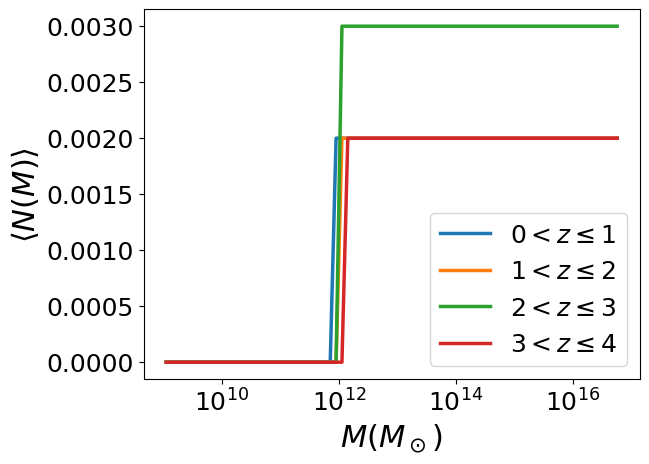

In [34]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))

plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

In [35]:
n_m_array, bins_M_min = [], []
for i in z_array:   
    bins_i = np.logspace(M_min_array[i], M_max, 79)
    n_m=np.ones(np.shape(bins_i))*fduty[i]
    n_m_array.append(n_m)
    bins_M_min.append(bins_i)

In [36]:
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.ones(np.shape(bins))*fduty[i]
        n_m_array_2D[i].append(n_m)

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [37]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), M_max, 79) for j in range(len(bins))]

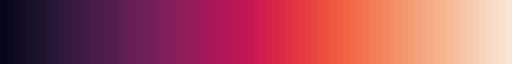

In [38]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

# Calculate derived parameters
## Plot b(z)

In [39]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_planck18): #quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [40]:
b_cf20 = np.load('../results/b_cf20_planck18.npy')
b_wp20 = np.load('../results/b_wp20_planck18.npy')

## Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [44]:
fac_rand = 25

In [45]:
tab_datahi_mask_zbins, selfunc_hi_bins = {L: [] for L in L_bins}, {L: [] for L in L_bins}

# for i in range(len(L_bins)):
i = 0            
for j in z_array:
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0, _, _ = quaia.make_bins(G_hi, [j, i], True, ['z', 'L'], 
                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data', 
                                                                                      method = ['minmax', 'max'], fac_rand = fac_rand, 
                                                                                      n_bins = [None, None], b = b, mask_type = 'b')
    tab_datahi_mask_zbins[L_bins[i]].append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins[L_bins[i]].append(selfunc_hi_bin0)

Pixels masked by MC but not already by selfunc: 2468
G20.5_zmin0.0zmax1.0_Lmax-20.0: 0.33              218365 vs 324336
Pixels masked by MC but not already by selfunc: 4785
G20.5_zmin1.0zmax2.0_Lmax-20.0: 0.30              453228 vs 648196
Pixels masked by MC but not already by selfunc: 2764
G20.5_zmin2.0zmax3.0_Lmax-20.0: 0.28              207602 vs 286508
Pixels masked by MC but not already by selfunc: 307
G20.5_zmin3.0zmax4.6_Lmax-20.0: 0.23              28043 vs 36458


In [46]:
LMC = SkyCoord(['05 23 34.6 -69 45 22'], unit=(u.hourangle, u.deg)) #https://simbad.u-strasbg.fr/simbad/sim-id?Ident=Large+Magellanic+Cloud

In [47]:
LMC_radius = 9*u.deg

In [48]:
SMC = SkyCoord(['00 52 38.0 -72 48 01'], unit=(u.hourangle, u.deg)) # https://simbad.u-strasbg.fr/simbad/sim-id?Ident=small+Magellanic+Cloud

In [49]:
SMC_radius = 5*u.deg

In [50]:
NPIX = hp.nside2npix(NSIDE)

In [51]:
theta, phi = hp.pix2ang(NSIDE, range(NPIX), lonlat=True)
c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
MC_idx = np.append(LMC_idx,SMC_idx)
MC_mask = np.full_like(range(NPIX), True, dtype = bool)
MC_mask[MC_idx] = False

In [52]:
selfunc_mask = np.abs(c.galactic.b.value)>=b

In [53]:
n_q, n_q_err, V_eff, N_q = {L: [] for L in L_bins}, {L: [] for L in L_bins}, {L: [] for L in L_bins}, {L: [] for L in L_bins}

# for i in range(len(L_bins)):
            
for j in z_array:   

    N = len(tab_datahi_mask_zbins[L_bins[i]][j])
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[L_bins[i]][j][selfunc_mask & MC_mask]*hp.nside2pixarea(NSIDE))
    V = f_sky*(Planck18.comoving_volume(z_bins[j+1])-Planck18.comoving_volume(z_bins[j]))*Planck18.h**3/u.h**3
    N_q[L_bins[i]].append(N)
    n_q[L_bins[i]].append(N/V.value)
    n_q_err[L_bins[i]].append(np.sqrt(N)/V.value) # Poisson error
    V_eff[L_bins[i]].append(V)
    print(np.sqrt(N)/N*100)
        
n_q_err

0.21399739416959668
0.14853938923101784
0.2194745834562775
0.5971559501134015


{-20.0: [2.306551403404182e-08,
  1.208077202021923e-08,
  6.8836698683460285e-09,
  1.6257950737213308e-09],
 -25.0: [],
 -26.0: [],
 -27.0: []}

In [54]:
fduty_err_hi = 0.002, 0.001, 0.008, 0.077
fduty_err_lo = 0.002, 0.001, 0.007, 0.034

In [55]:
def n_q_theory_err(n_dm, fduty_err, M_min, a, M_min_err, hmf = hmf, cosmo = cosmo_planck18): #quaia):
    
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.sqrt(n_dm**2*fduty_err**2+(fduty_err*hmf(cosmo, 10**M_min, a))**2*M_min_err**2)

## Calculate extent of Limber approximation

In [56]:
def theta_break(slope, sigma, rm):

    return 2*np.sqrt(3)/np.sqrt(np.pi)*gamma(slope/2)/gamma(slope/2-1/2)*sigma/rm*u.rad

In [57]:
slope = [1.89, 1.89, 1.89, 2.13]

In [58]:
# for i in range(len(L_bins)):

print('M_i<={}'.format(L_bins[i]))

for j in z_array:

    print('{:.1f}<z<={:.1f}\n'.format(z_bins[j], z_bins[j+1]))
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0, _, _ = quaia.make_bins(
        G_hi, [j, i], True, ['z', 'L'], bins = [z_bins, L_bins], tab_gcat_type = 'data', method = ['minmax', 'max'], fac_rand = fac_rand, 
        n_bins = [None, None], b = b, mask_type = 'b', verbose = False)

    z = np.mean(tab_datahi_mask_zbin0['redshift_quaia'])
    rm = quaia.comoving_dist(z)
    sigma = quaia.comoving_dist(z+np.mean(tab_datahi_mask_zbin0['redshift_quaia_err']))-rm
    theta = theta_break(slope[j], sigma, rm)
    
    print('sigma/rm      : {:.2f}'.format(sigma/rm))
    print('10% error     : {:.2f}'.format(260*sigma/rm*u.arcmin))
    print('10% error     : {:.2f}'.format((260*sigma/rm*u.arcmin).to(u.deg)))
    print('theta_break   : {:.2f}'.format(theta))
    print('theta_break/10: {:.2f}\n'.format(theta.to(u.deg)))

M_i<=-20.0
0.0<z<=1.0

sigma/rm      : 0.14
10% error     : 35.31 arcmin
10% error     : 0.59 deg
theta_break   : 0.14 rad
theta_break/10: 7.91 deg

1.0<z<=2.0

sigma/rm      : 0.07
10% error     : 18.94 arcmin
10% error     : 0.32 deg
theta_break   : 0.07 rad
theta_break/10: 4.24 deg

2.0<z<=3.0

sigma/rm      : 0.04
10% error     : 10.36 arcmin
10% error     : 0.17 deg
theta_break   : 0.04 rad
theta_break/10: 2.32 deg

3.0<z<=4.6

sigma/rm      : 0.02
10% error     : 5.83 arcmin
10% error     : 0.10 deg
theta_break   : 0.03 rad
theta_break/10: 1.54 deg



## Calculate min scale to avoid 1-halo term
[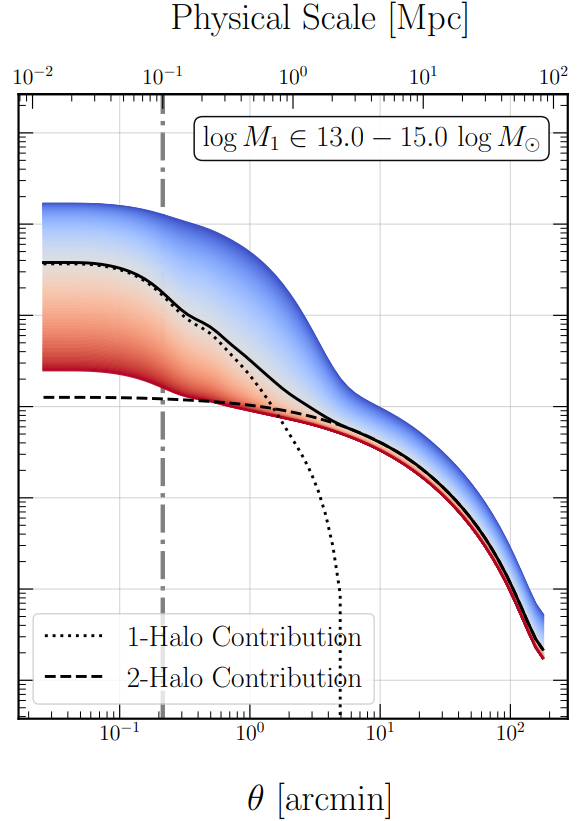](https://arxiv.org/abs/2510.11780)

In [53]:
np.log10((5*u.arcmin).to(u.deg).value), np.log10(0.01)

(-1.0791812460476249, -2.0)

## Limit angular scales to $0.001^\circ\geq \theta \geq 10^\circ$

In [54]:
# Create the bins array
# rmin = 0.1
# rmax = 25.0
# nbins = 10 #14
# thetabins = np.logspace(np.log10(rmin), np.log10(rmax), nbins+1) #(np.log10(0.15), np.log10(35), 15)

# Create the bins array
rmin = 0.001
rmax = 10.0
nbins = 30 #20 #30 #20
thetabins = np.logspace(np.log10(rmin), np.log10(rmax), nbins+1)
np.log10(thetabins), quaia.recenter(np.log10(thetabins)), np.diff(np.log10(thetabins))

(array([-3.        , -2.86666667, -2.73333333, -2.6       , -2.46666667,
        -2.33333333, -2.2       , -2.06666667, -1.93333333, -1.8       ,
        -1.66666667, -1.53333333, -1.4       , -1.26666667, -1.13333333,
        -1.        , -0.86666667, -0.73333333, -0.6       , -0.46666667,
        -0.33333333, -0.2       , -0.06666667,  0.06666667,  0.2       ,
         0.33333333,  0.46666667,  0.6       ,  0.73333333,  0.86666667,
         1.        ]),
 array([-2.93333333e+00, -2.80000000e+00, -2.66666667e+00, -2.53333333e+00,
        -2.40000000e+00, -2.26666667e+00, -2.13333333e+00, -2.00000000e+00,
        -1.86666667e+00, -1.73333333e+00, -1.60000000e+00, -1.46666667e+00,
        -1.33333333e+00, -1.20000000e+00, -1.06666667e+00, -9.33333333e-01,
        -8.00000000e-01, -6.66666667e-01, -5.33333333e-01, -4.00000000e-01,
        -2.66666667e-01, -1.33333333e-01, -2.42861287e-16,  1.33333333e-01,
         2.66666667e-01,  4.00000000e-01,  5.33333333e-01,  6.66666667e-01,
       

In [55]:
pimax = 80 # 40 # 5000.0 # 40.0\

In [56]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

## Pick cosmology

In [57]:
cosmo = 'Planck'

In [58]:
N = 50 #20 #65 #50 #30 #15 #80

In [59]:
wp_chi2, wp_matter_chi2, rpavg_chi2 = {L: [] for L in L_bins}, {L: [] for L in L_bins}, {L: [] for L in L_bins}
a_zbin, b_wp_q = {L: [] for L in L_bins}, {L: [] for L in L_bins}
H0 = Planck18.H0 # cosmo_planck18['H0'] * u.km/u.s/u.Mpc
for i in range(len(L_bins)):
            
    for j in z_array:                                                               

        wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
        a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))
      
        wp_chi2[L_bins[i]].append(wp_zbin_i)

        # scale factor
        a_zbin[L_bins[i]].append(a)
    
        # matter correlation function   
        # s = np.sqrt(np.sum(np.meshgrid(np.array(rpavg_zbin_i)**2, quaia.recenter(pibins)**2), axis = 0))
        # s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
            
        # xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo_planck18, r=np.ravel(s_Mpc), a=a)
        # wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)
        # wp_matter_chi2[L_bins[i]].append(wp_matter_zbin_i)        
    
        # effective bias 
        # b_q = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
        # b_wp_chi2[L_bins[i]].append(b_q)
    
        # qso bias
        # b_wp_q[L_bins[i]].append(b_qso(wp_zbin_i, wp_matter_zbin_i, ccl.growth_rate(cosmo_planck18, a)))

In [60]:
theta_mask=(quaia.recenter(np.log10(thetabins))>=-2) & (quaia.recenter(np.log10(thetabins))<=0)
np.log10(quaia.recenter(thetabins)[theta_mask])

array([-1.99490311, -1.86156978, -1.72823645, -1.59490311, -1.46156978,
       -1.32823645, -1.19490311, -1.06156978, -0.92823645, -0.79490311,
       -0.66156978, -0.52823645, -0.39490311, -0.26156978, -0.12823645,
        0.00509689])

In [61]:
offset = 0.3

In [62]:
delta_xlim = np.diff(np.log10(thetabins))[0]/2
delta_xlim/2, thetabins, 10**(np.log10(thetabins) - 2*delta_xlim)

(0.033333333333333326,
 array([1.00000000e-03, 1.35935639e-03, 1.84784980e-03, 2.51188643e-03,
        3.41454887e-03, 4.64158883e-03, 6.30957344e-03, 8.57695899e-03,
        1.16591440e-02, 1.58489319e-02, 2.15443469e-02, 2.92864456e-02,
        3.98107171e-02, 5.41169527e-02, 7.35642254e-02, 1.00000000e-01,
        1.35935639e-01, 1.84784980e-01, 2.51188643e-01, 3.41454887e-01,
        4.64158883e-01, 6.30957344e-01, 8.57695899e-01, 1.16591440e+00,
        1.58489319e+00, 2.15443469e+00, 2.92864456e+00, 3.98107171e+00,
        5.41169527e+00, 7.35642254e+00, 1.00000000e+01]),
 array([7.35642254e-04, 1.00000000e-03, 1.35935639e-03, 1.84784980e-03,
        2.51188643e-03, 3.41454887e-03, 4.64158883e-03, 6.30957344e-03,
        8.57695899e-03, 1.16591440e-02, 1.58489319e-02, 2.15443469e-02,
        2.92864456e-02, 3.98107171e-02, 5.41169527e-02, 7.35642254e-02,
        1.00000000e-01, 1.35935639e-01, 1.84784980e-01, 2.51188643e-01,
        3.41454887e-01, 4.64158883e-01, 6.30957344e-01,

In [63]:
cmap_theta = sns.color_palette("cubehelix", n_colors = len(L_bins))
cmap_theta

[(0.08605633600581403, 0.23824692404212, 0.30561236308077167),
 (0.32927729263408284, 0.4762845556584382, 0.1837155549758328),
 (0.8146245329198283, 0.49548316572322215, 0.5752525936416857),
 (0.7587183008012618, 0.7922069335474338, 0.9543861221913403)]

In [64]:
10**(np.log10(quaia.recenter(thetabins)) + i*delta_xlim/2)

array([1.48512686e-03, 2.01881669e-03, 2.74429136e-03, 3.73047000e-03,
       5.07103824e-03, 6.89334824e-03, 9.37051699e-03, 1.27378721e-02,
       1.73153079e-02, 2.35376745e-02, 3.19960882e-02, 4.34940870e-02,
       5.91239651e-02, 8.03705399e-02, 1.09252207e-01, 1.48512686e-01,
       2.01881669e-01, 2.74429136e-01, 3.73047000e-01, 5.07103824e-01,
       6.89334824e-01, 9.37051699e-01, 1.27378721e+00, 1.73153079e+00,
       2.35376745e+00, 3.19960882e+00, 4.34940870e+00, 5.91239651e+00,
       8.03705399e+00, 1.09252207e+01])

<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12313/3105498261.py:22: SyntaxWarning: invalid escape sequence '\l'
  yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = '$M_i\leq{}$'.format(L_bins[i])) #capsize = 2.5
/tmp/ipykernel_12313/3105498261.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))


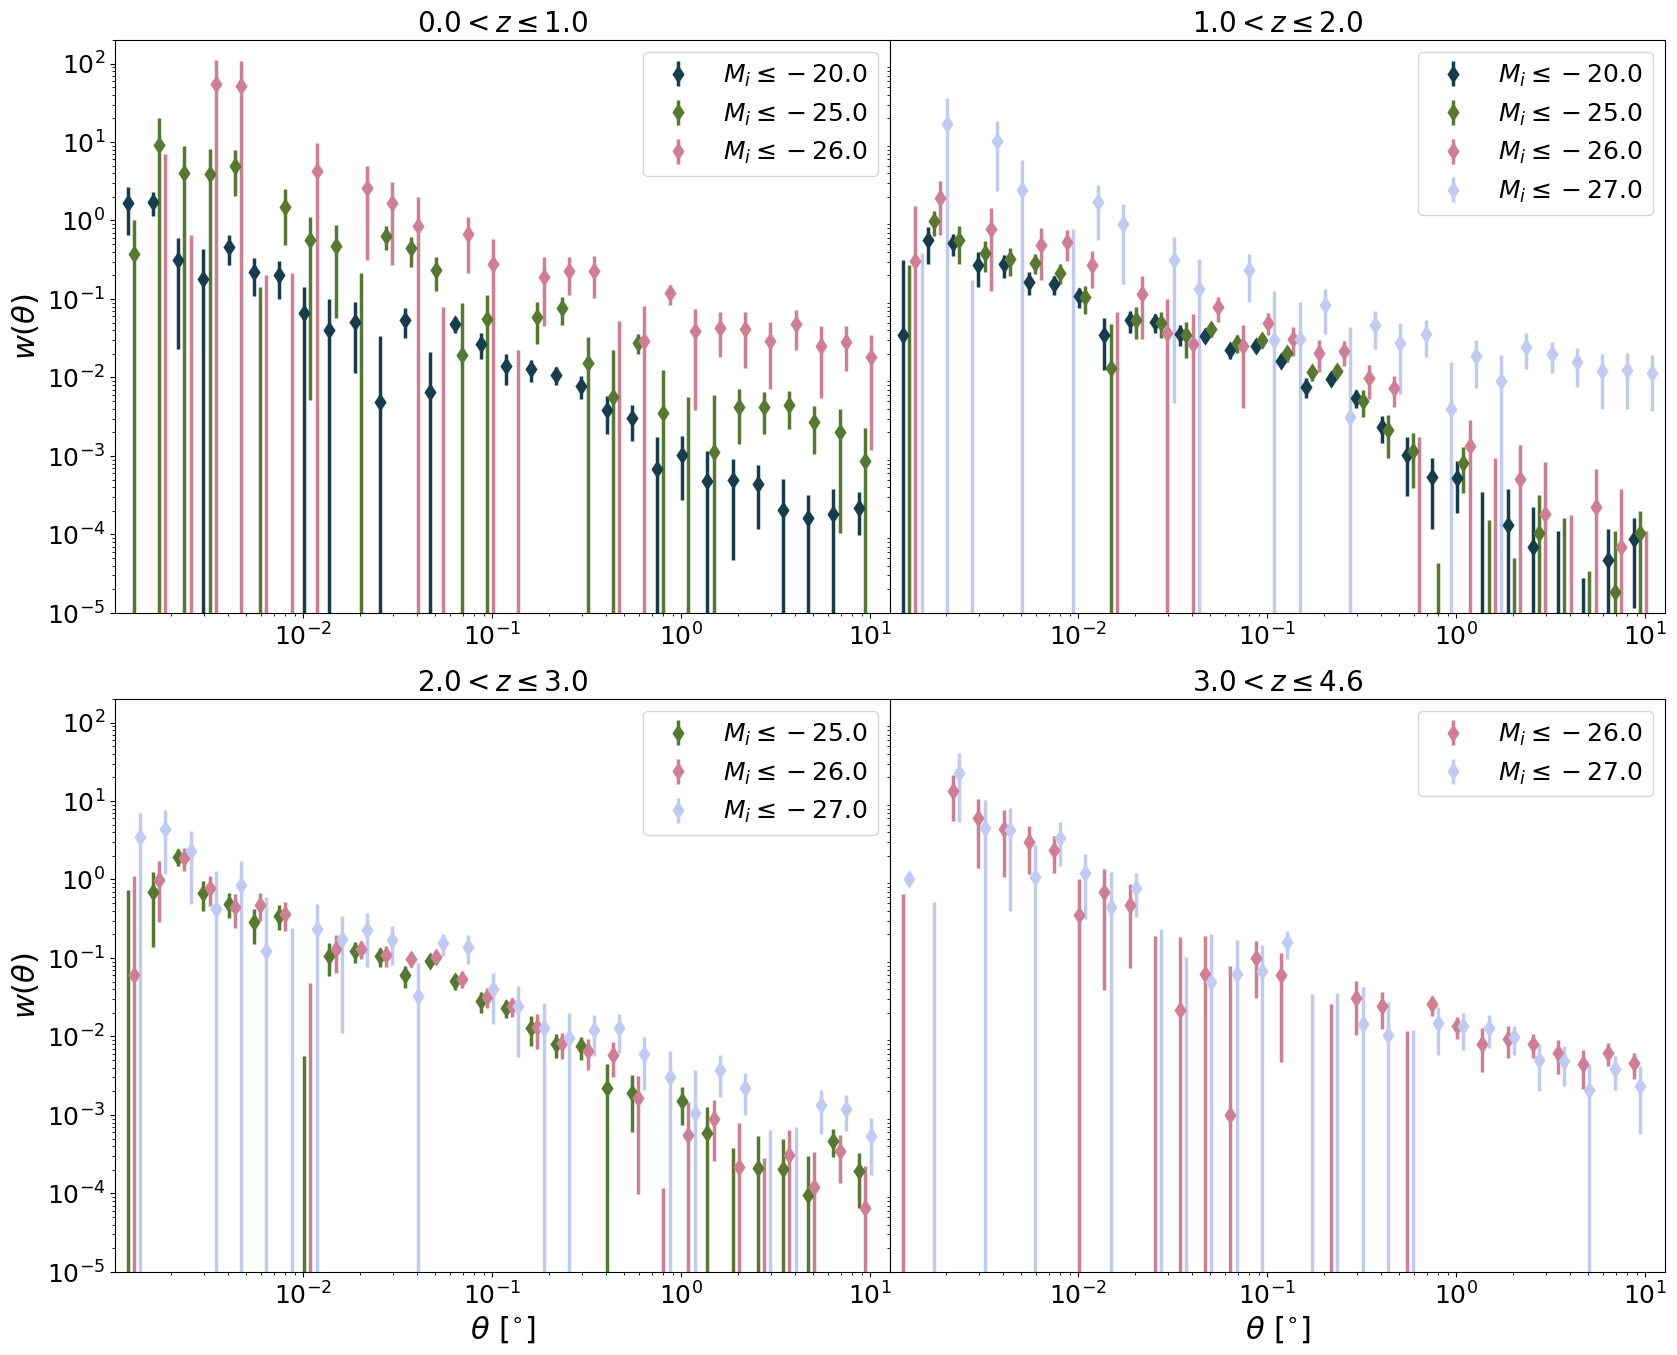

In [65]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

# remove bottom panel and just print bq somewhere
# plot!
for j in range(len(z_array)):

    ax1 = fig.add_subplot(gs[j])

    k=0
    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):
            
            sigma = np.sqrt(np.diag(np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))))
            wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
            a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))            
            
            ax1.errorbar(10**(np.log10(quaia.recenter(thetabins)) + k*delta_xlim/2), wp_zbin_i, linewidth = 2.5, marker = 'd', color = cmap_theta[i],
                        yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = '$M_i\leq{}$'.format(L_bins[i])) #capsize = 2.5

            ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
            ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + 5/2*delta_xlim))
            ax1.set_yscale('log')
            ax1.set_xscale('log')
            ax1.set_ylim(1e-5, 2e2)
            
            if j%2==0:
                ax1.set_ylabel(r"$w(\theta)$")
            else:
                ax1.set_yticks([])
            if j > 1:
                ax1.set_xlabel(r'$\theta$ $[^{\circ}]$') 
            ax1.legend(loc = 'upper right')

            k+=1

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12313/2225607023.py:21: SyntaxWarning: invalid escape sequence '\l'
  yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1])) #capsize = 2.5
/tmp/ipykernel_12313/2225607023.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))


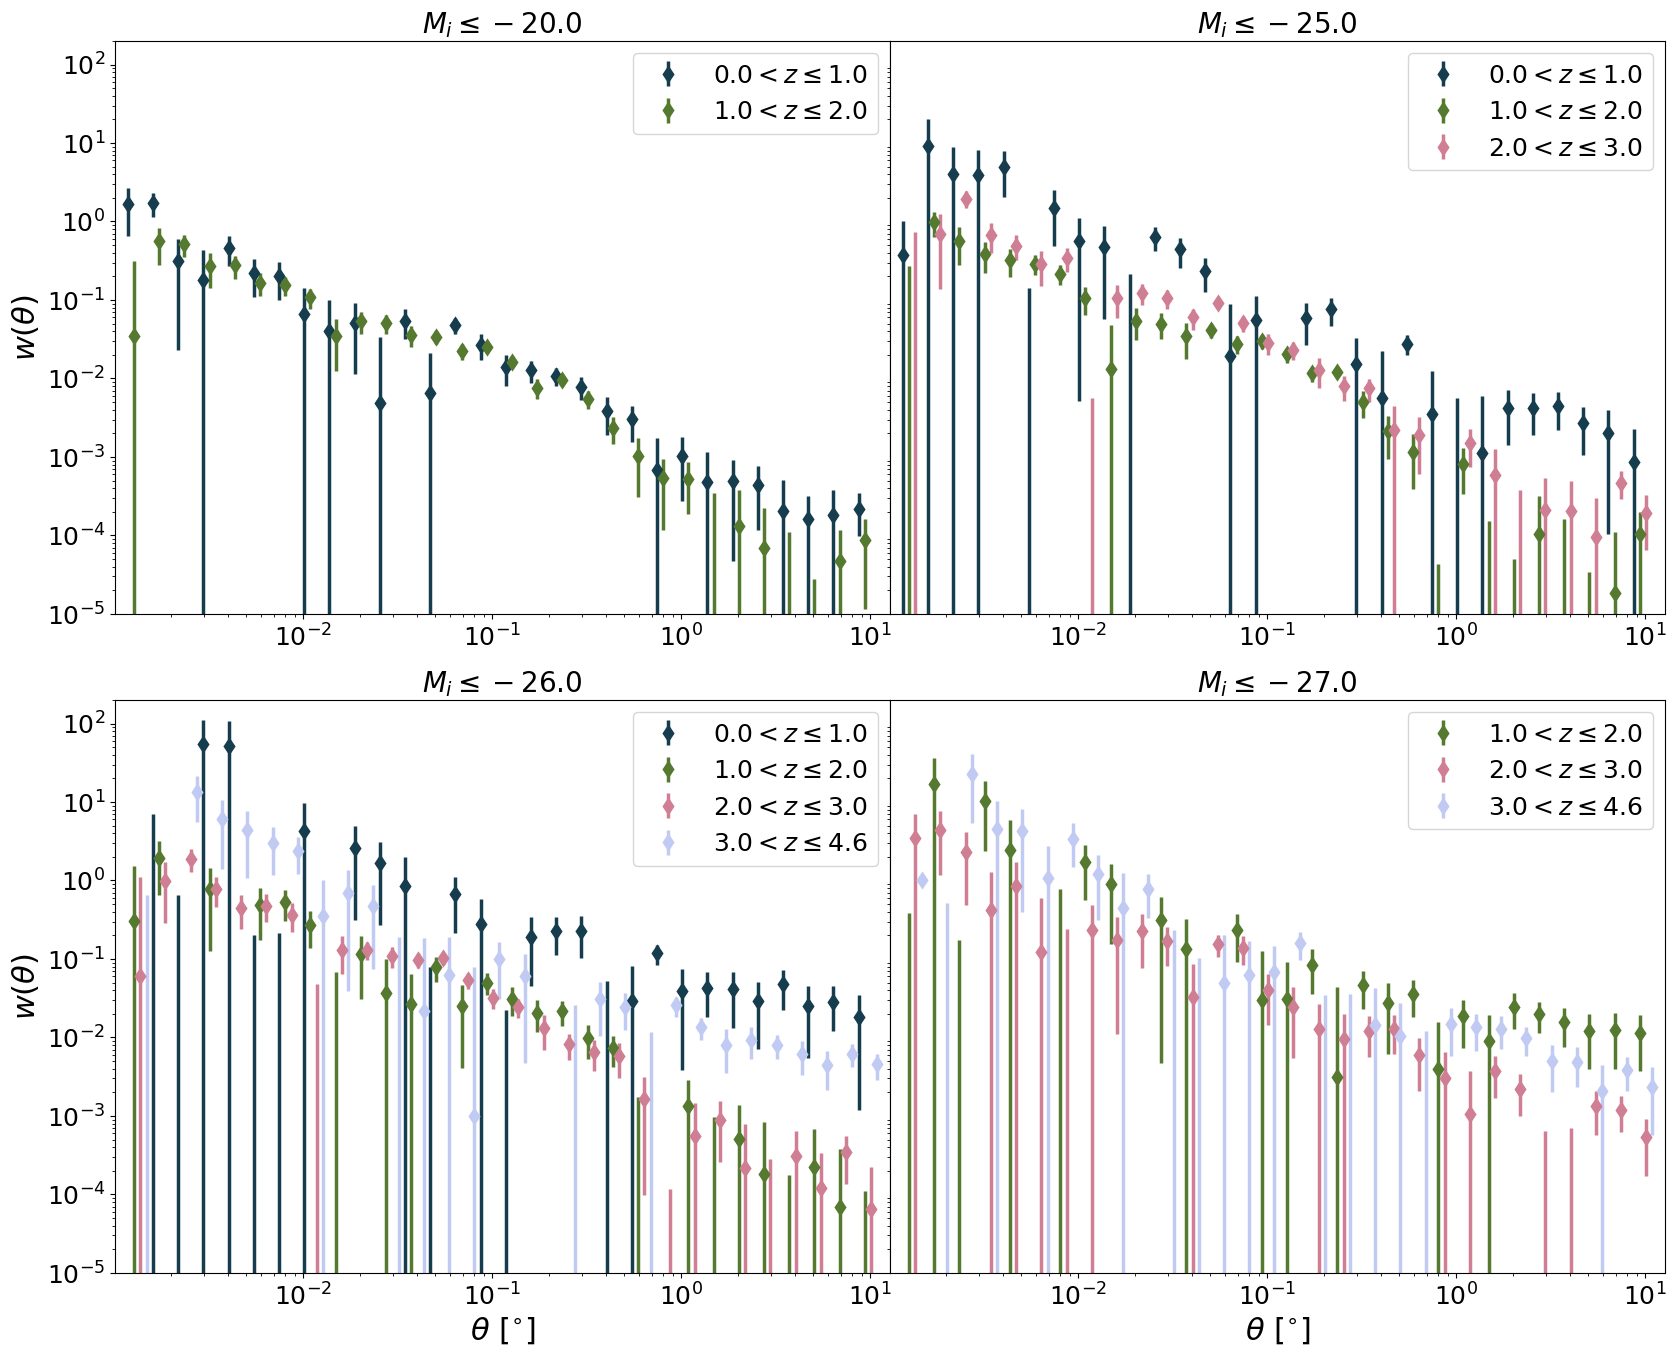

In [66]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

# remove bottom panel and just print bq somewhere
# plot!
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i])

    for j in range(len(z_array)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            sigma = np.sqrt(np.diag(np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))))
            wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
            a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))            
            
            ax1.errorbar(10**(np.log10(quaia.recenter(thetabins)) + j*delta_xlim/2), wp_zbin_i, linewidth = 2.5, marker = 'd', color = cmap_theta[j],
                        yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1])) #capsize = 2.5

            ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + 5/2*delta_xlim))
            ax1.set_yscale('log')
            ax1.set_xscale('log')
            ax1.set_ylim(1e-5, 2e2)
            
            if i%2==0:
                ax1.set_ylabel(r"$w(\theta)$")
            else:
                ax1.set_yticks([])
            if i > 1:
                ax1.set_xlabel(r'$\theta$ $[^{\circ}]$') 
            ax1.legend(loc = 'upper right')

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12313/781678753.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
/tmp/ipykernel_12313/781678753.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax1.errorbar(quaia.recenter(thetabins), wp_zbin_i, marker = 'd', label = '${:.0f}^\mathrm{{th}}$ percentile'.format(mask*100), markeredgewidth = 2.5,# capsize = 2.5,


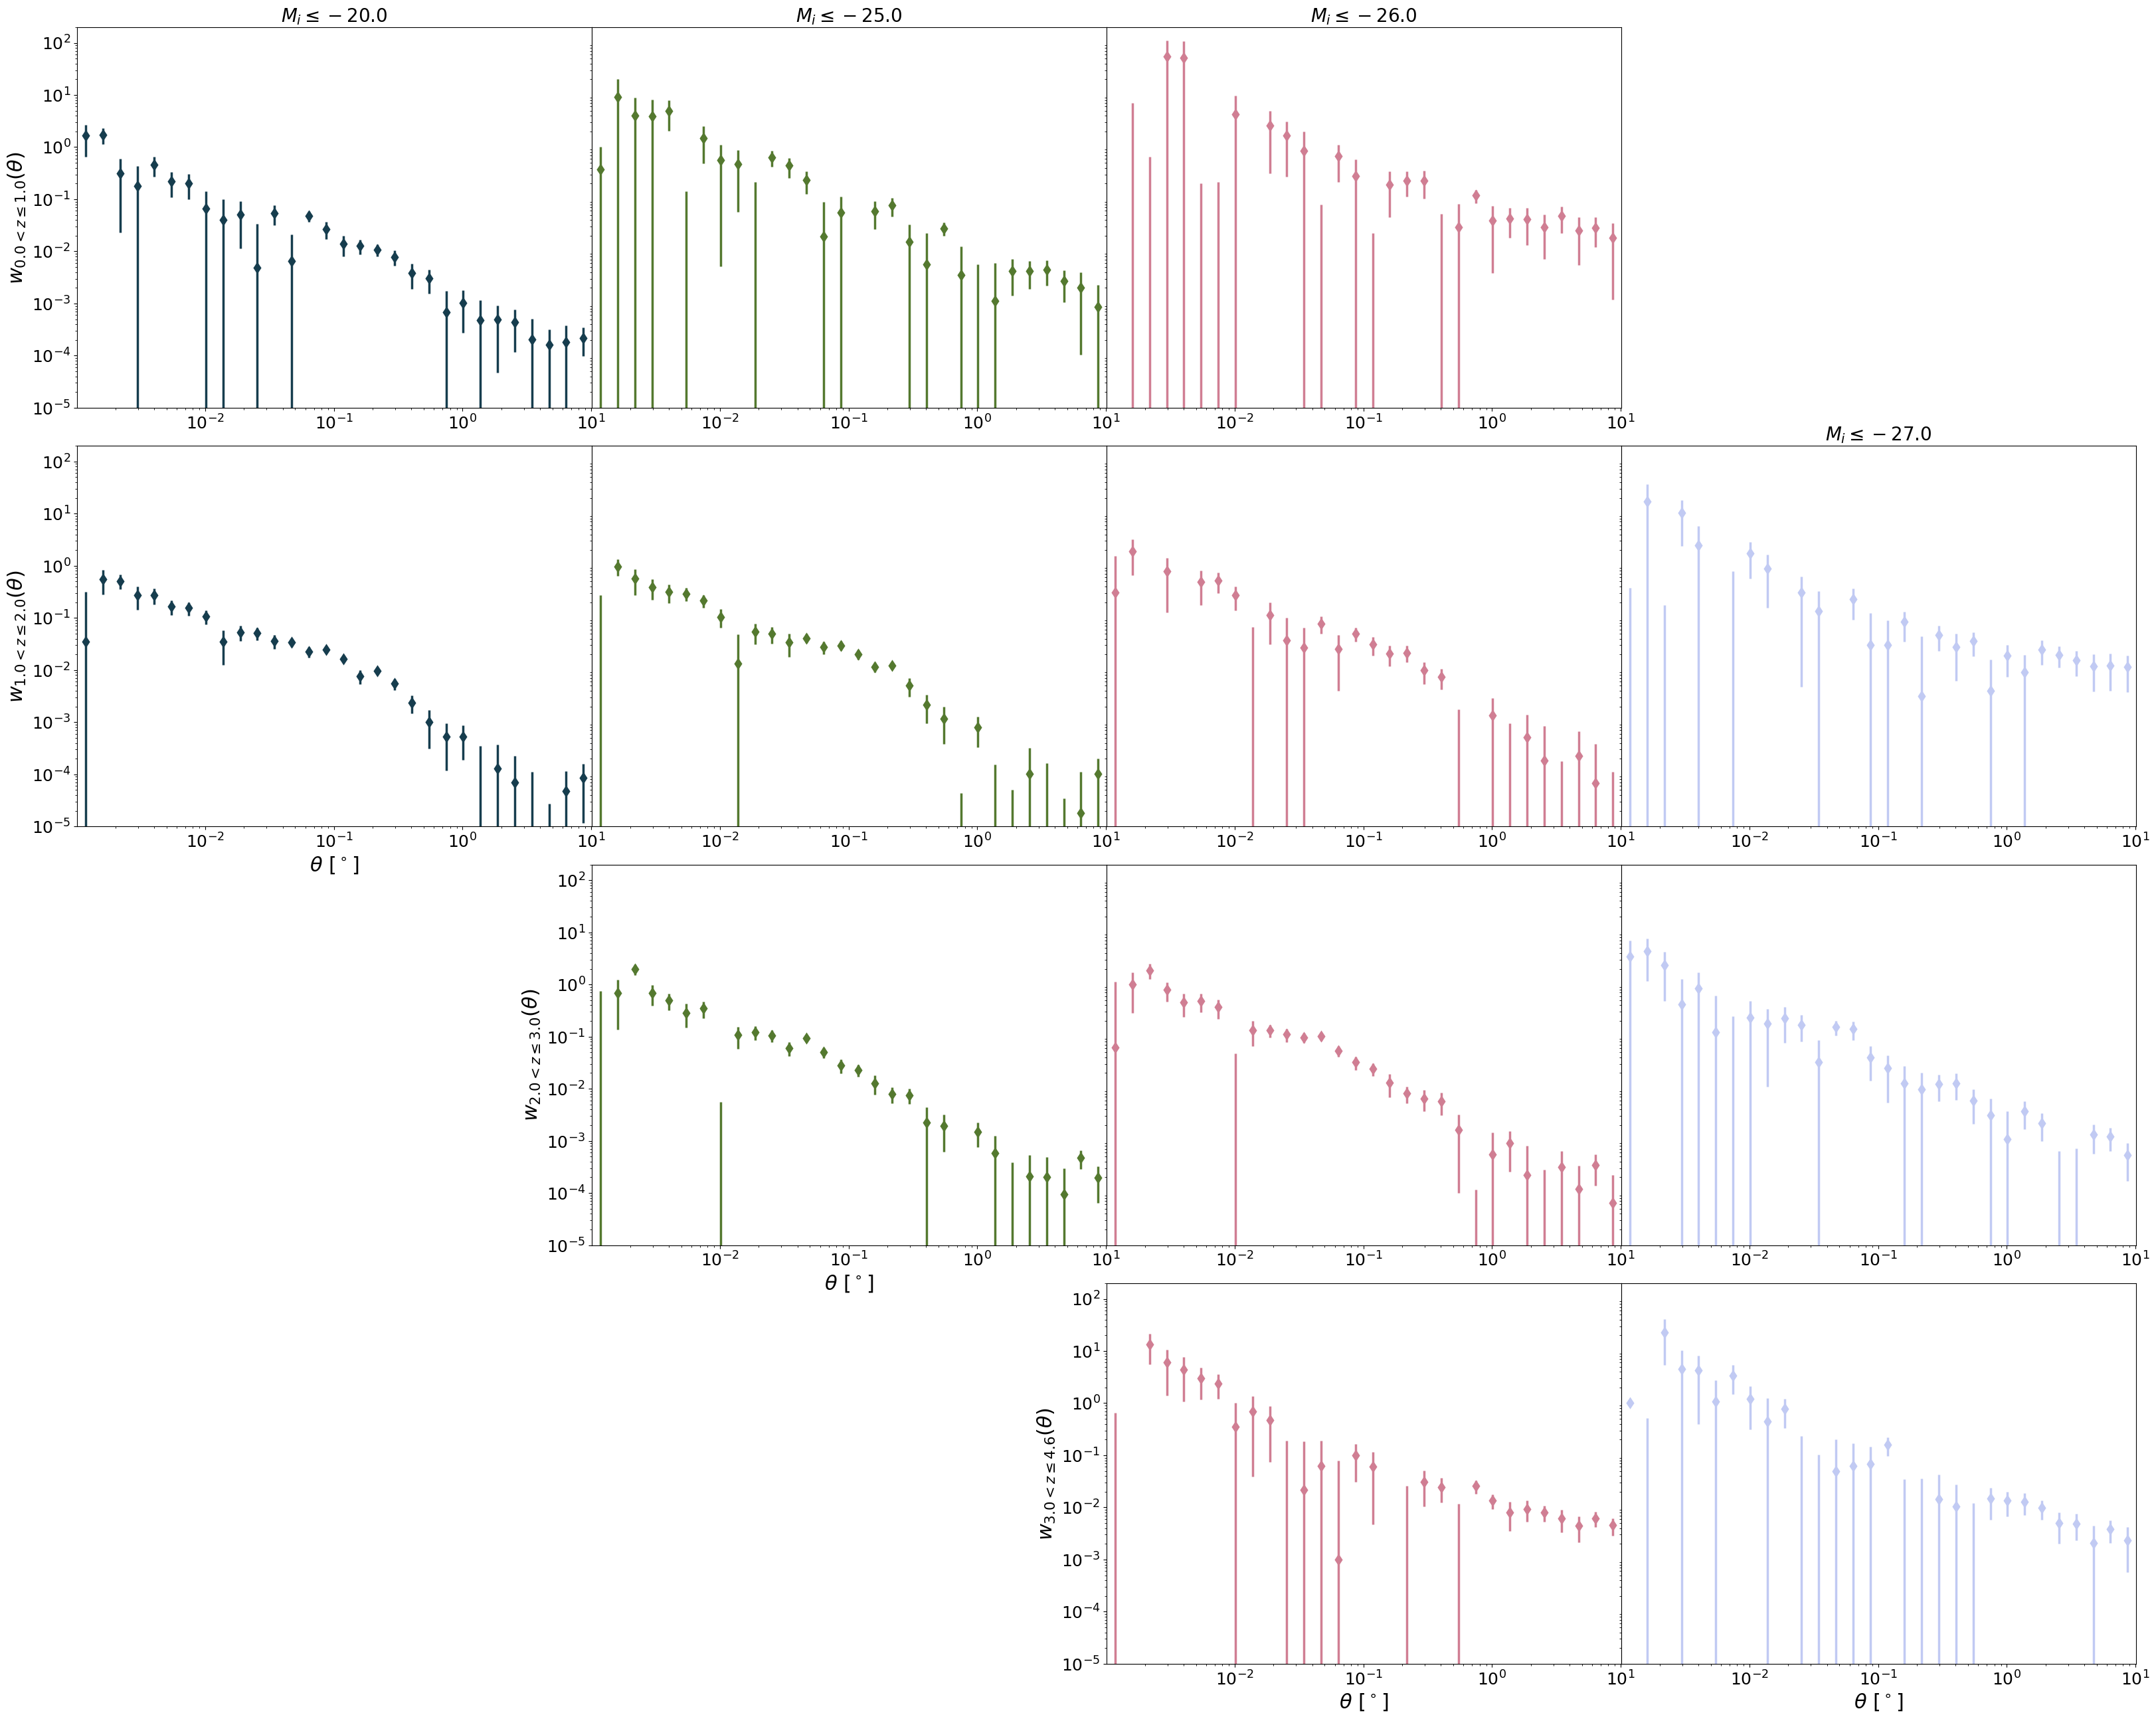

In [67]:
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)
k = 3
b=30
for j in z_array:
    
    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):
                
            ax1 = fig.add_subplot(gs[j*4+i])

            if (j ==0) or ((j == 1) and (i == 3)):
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_ylim(1e-5, 2e2)
            
            if j > 2 or ((j>0) and (i <2) and (i!=j)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected
            if i==0 or ((j>1) and (i <3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))
            else:
                ax1.set_yticks([])
            ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
                          
            wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
            a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))            
            sigma = np.sqrt(np.diag(np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))))
                        
            ax1.errorbar(quaia.recenter(thetabins), wp_zbin_i, marker = 'd', label = '${:.0f}^\mathrm{{th}}$ percentile'.format(mask*100), markeredgewidth = 2.5,# capsize = 2.5,
                     linewidth = 2.5, color = cmap_theta[i], yerr = sigma, linestyle = 'none')

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12313/597762826.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
/tmp/ipykernel_12313/597762826.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax1.errorbar(quaia.recenter(thetabins), wp_zbin_i, marker = 'd', label = '${:.0f}^\mathrm{{th}}$ percentile'.format(mask*100), markeredgewidth = 2.5,# capsize = 2.5,


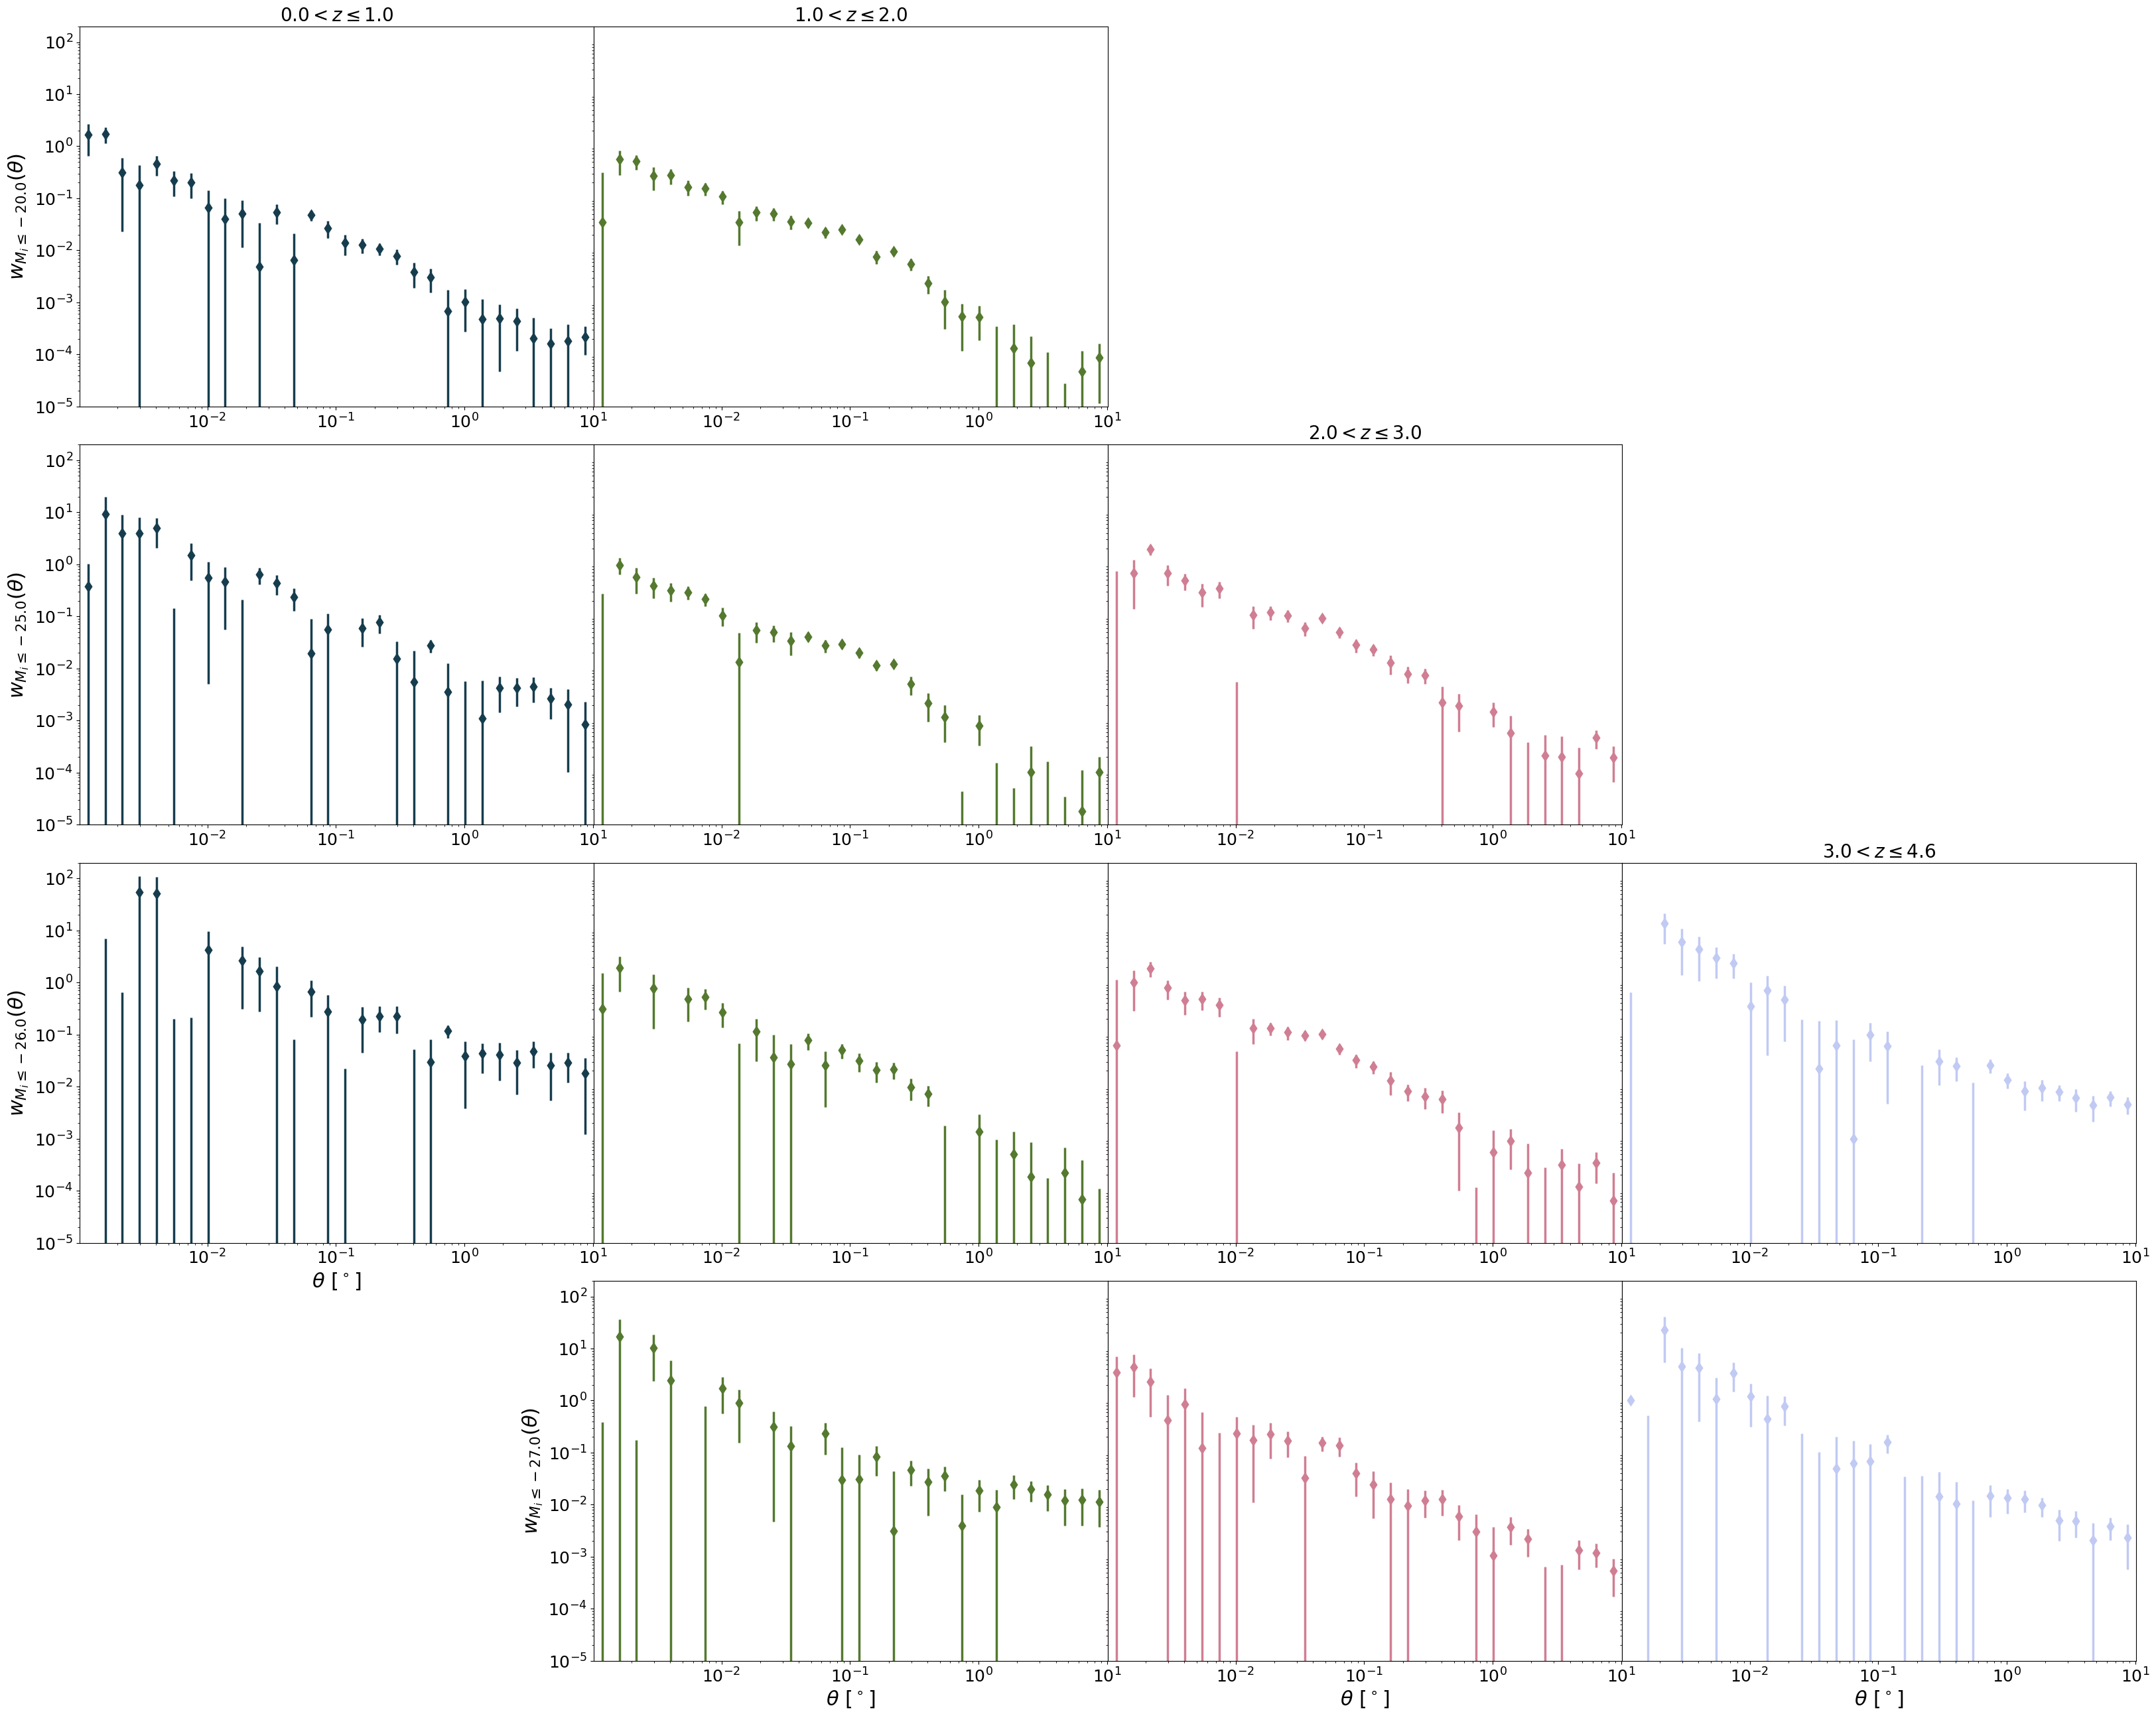

In [68]:
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)
k = 3
b=30
for i in range(len(L_bins)):

    for j in z_array:
    
        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):
                
            ax1 = fig.add_subplot(gs[i*4+j])

            if i ==0 or ((i<3) and (j>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
            ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_ylim(1e-5, 2e2)
            
            if i > 2 or ((i ==2) and (j == 0)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected
            if j==0 or ((j == 1) and (i == 3)):
                ax1.set_ylabel(r"$w_{{M_i\leq{}}}(\theta)$".format(L_bins[i]))
            else:
                ax1.set_yticks([])
            ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
                            
            wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
            a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))            
            sigma = np.sqrt(np.diag(np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))))
                        
            ax1.errorbar(quaia.recenter(thetabins), wp_zbin_i, marker = 'd', label = '${:.0f}^\mathrm{{th}}$ percentile'.format(mask*100), markeredgewidth = 2.5,# capsize = 2.5,
                     linewidth = 2.5, color = cmap_theta[j], yerr = sigma, linestyle = 'none')

plt.show()

# Perform nested sampling with dynesty

In [69]:
# Define the dimensionality of our problem.
ndim = 1 #2

### Implement Limber approximation: $w(\theta)=\int d z \frac{H(z)}{c}\left(\frac{d N}{d z}\right)^2 \int \frac{d k k}{2 \pi} P_{q q} J_0[k \theta \chi(z)]=\int d z \frac{H(z)}{c}\left(\frac{d N}{d z}\right)^2 w_p(\theta \chi(z))$

In [70]:
theta_min = (rmin*u.deg).to(u.rad)
theta_max = (rmax*u.deg).to(u.rad)

zmin = 1/a_zbin[L_bins[0]][0]-1
zmax = 1/a_zbin[L_bins[-1]][-1]-1

lambda_min = theta_min*quaia.comoving_dist(zmin, units = 'Mpc')/(1+zmin) # angular diameter distance
lambda_max = theta_max*quaia.comoving_dist(zmax, units = 'Mpc')/(1+zmax)
# lambda_min = theta_min*ccl.background.comoving_radial_distance(cosmo_planck18, a_zbin[L_bins[0]][0])
# lambda_max = theta_max*ccl.background.comoving_radial_distance(cosmo_planck18, a_zbin[L_bins[-1]][-1])
print(lambda_min, lambda_max)

k_max = 2*np.pi/lambda_min
k_min = 2*np.pi/lambda_max
print(k_min, k_max)

np.log10(k_min.value), np.log10(k_max.value) 

0.026595543947174446 Mpc rad 275.05831099657445 Mpc rad
0.022843102920303456 1 / (Mpc rad) 236.24955066381042 1 / (Mpc rad)


(-1.6412449035069128, 2.373370991173202)

In [71]:
k_log = np.logspace(-2, 3) #-4, 2)

In [72]:
(rmax*u.deg).to(u.rad)*quaia.comoving_dist(4.6)/(1+4.6)

<Quantity 164.41711641 Mpc rad / littleh>

In [73]:
def wp_2h(bins, n_m, a, cosmo, wp_matter_zbin_i, rpbins, pibins = pibins, recenter = True, rpmask = True):

    if not isinstance(wp_matter_zbin_i, np.ndarray):

        # print('computing wp_matter')
        
        # matter correlation function    
        if isinstance(rpmask, bool):
            rpmask = [rpmask]*len(quaia.recenter(rpbins))
            
        s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)[rpmask]**2, quaia.recenter(pibins)**2), axis = 0))
        s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(cosmo['h']* 100 * u.km/u.s/u.Mpc))

        xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo, r=np.ravel(s_Mpc), a=a)
        wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)

    return cf_2h(bins, n_m, a, cosmo, wp_matter_zbin_i, recenter = recenter)

In [74]:
dz = np.linspace(0, 4.6)

In [75]:
rpbins = [(thetabins*u.deg).to(u.rad)*quaia.comoving_dist(z, units = 'Mpc') for z in dz]
np.max(rpbins)

1345.3183107547193

In [76]:
dN_dz = np.sum(stats.norm.pdf(dz[None, :], loc=tab_datahi_mask_zbin0['redshift_quaia'][:, None], scale=tab_datahi_mask_zbin0['redshift_quaia_err'][:, None]), axis = 0)
norm = np.sum(stats.norm.cdf(dz[-1], loc=tab_datahi_mask_zbin0['redshift_quaia'], scale=tab_datahi_mask_zbin0['redshift_quaia_err']))
# dN_dz/=norm

In [77]:
bins_m = np.logspace(12, M_max, 79)
n_m=np.ones(len(bins_m))*1e-3

In [78]:
def wtheta_2h(bins, n_m, dN_dz, wp = False, thetabins = thetabins, dz = dz, k = k_log, recenter = False,
              theta_mask = np.full_like(quaia.recenter(thetabins), True, dtype = bool), rpbins = rpbins):

    hankel = mcfit.Hankel(k, lowring = True)

    # compute for each z... for statement?
    b_q, k_integral, a, n_g = [], [], [], []
    for i, z in enumerate(dz):
        a.append(1/(1+z))
        # rpbins = (thetabins*u.deg).to(u.rad)*quaia.comoving_dist(z, units = 'Mpc')
        b_z, n_z = bias(bins, n_m, a[i], cosmo_planck18, recenter = recenter)
        # print(b_z)
        if wp:
            wp_z, _ = wp_2h(bins, n_m, a[i], cosmo_planck18, False, rpbins[i], recenter = recenter)
        else:
            P_qq = b_z**2*ccl.power.linear_matter_power(cosmo_planck18, k, a[i])
            # print(P_qq)
            rpbins_k, wp_k = hankel(P_qq/(2*np.pi))
            # print(quaia.recenter(rpbins).value[theta_mask])
            wp_z = np.interp(quaia.recenter(rpbins[i]).value[theta_mask], rpbins_k, wp_k)
            
        k_integral.append(wp_z) # as a function of rp
        b_q.append(b_z)
        n_g.append(n_z)
        
    z_integrand = [ccl.background.h_over_h0(cosmo_planck18, a[i])*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*dN_dz[i]**2*k_integral[i] 
                   for i in range(len(dz))]
    
    return np.trapz(z_integrand, dz, axis = 0), np.trapz(b_q*dN_dz, dz) #np.trapz(b_q*np.array(n_g)*dN_dz, z_array)/np.trapz(n_g*dN_dz, z_array)

In [79]:
P_mm = [ccl.power.linear_matter_power(cosmo_planck18, k_log, 1/(1+z)) for z in dz]

In [80]:
H0_c_dN_dz = [ccl.background.h_over_h0(cosmo_planck18, 1/(1+dz[i]))*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*(dN_dz[i]/norm)**2 for i in range(len(dz))]

In [81]:
def wtheta_2h_optimized(bins, n_m, H0_c_dN_dz, P_mm = P_mm, wp = False, thetabins = thetabins, dz = dz, k = k_log, recenter = False, 
                        theta_mask = np.full_like(quaia.recenter(thetabins), True, dtype = bool), rpbins = rpbins, 
                        hankel = mcfit.Hankel(k_log, lowring = True)):

    # compute for each z... for statement?
    k_integral = []
    for i, z in enumerate(dz):
        a = 1/(1+z)
        b_z, n_z = bias(bins, n_m, a, cosmo_planck18, recenter = recenter)
        if wp:
            wp_z, _ = wp_2h(bins, n_m, a, cosmo_planck18, False, rpbins[i], recenter = recenter)
        else:
            P_qq = b_z**2*P_mm[i]
            rpbins_k, wp_k = hankel(P_qq/(2*np.pi))
            wp_z = np.interp(quaia.recenter(rpbins[i]).value[theta_mask], rpbins_k, wp_k)
            
        k_integral.append(wp_z) # as a function of rp
        
    z_integrand = [H0_c_dN_dz[i]*k_integral[i] for i in range(len(dz))]
    
    return np.trapz(z_integrand, dz, axis = 0)#, np.trapz(b_q*dN_dz, z_array) #np.trapz(b_q*np.array(n_g)*dN_dz, z_array)/np.trapz(n_g*dN_dz, z_array)

In [82]:
# wtheta_2h_wp, b_q_wp = wtheta_2h(bins_m, n_m, dN_dz/norm, wp = True)
wtheta_2h_wp = wtheta_2h_optimized(bins_m, n_m, H0_c_dN_dz, wp = True)

In [83]:
# wtheta_2h_P, b_q_P = wtheta_2h(bins_m, n_m, dN_dz/norm)
wtheta_2h_P = wtheta_2h_optimized(bins_m, n_m, H0_c_dN_dz)

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_31223/4251549282.py:21: SyntaxWarning: invalid escape sequence '\l'
  yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = '$M_i\leq{}$'.format(L_bins[i])) #capsize = 2.5
/tmp/ipykernel_31223/4251549282.py:26: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
/tmp/ipykernel_31223/4251549282.py:21: SyntaxWarning: invalid escape sequence '\l'
  yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = '$M_i\leq{}$'.format(L_bins[i])) #capsize = 2.5
/tmp/ipykernel_31223/4251549282.py:26: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))


NameError: name 'rmin' is not defined

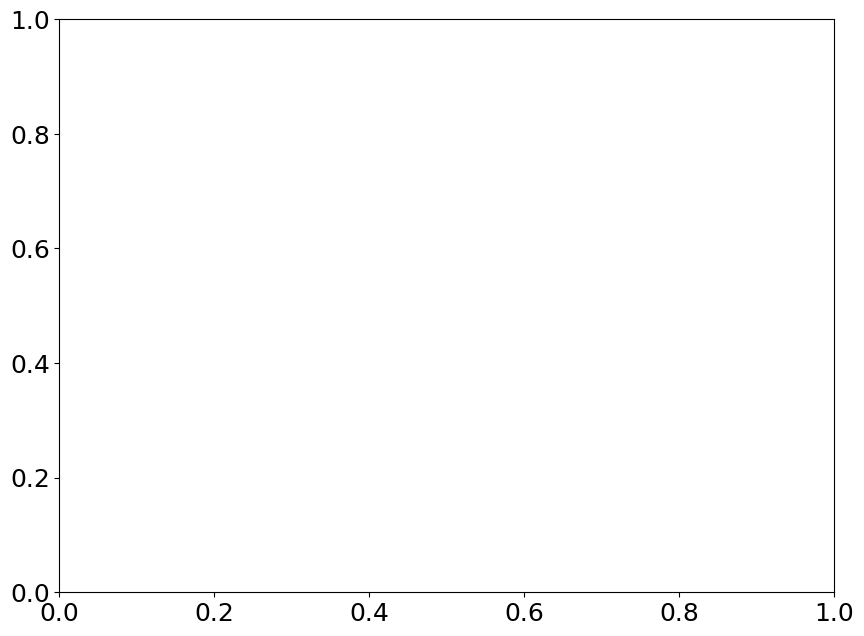

In [59]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

# remove bottom panel and just print bq somewhere
# plot!
# for j in range(len(z_array)):

ax1 = fig.add_subplot(gs[0])

    # for i in range(len(L_bins)):

        # if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

sigma = np.sqrt(np.diag(np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))))
wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))            

ax1.errorbar(quaia.recenter(thetabins), wp_zbin_i, linewidth = 2.5, marker = 'd', color = cmap_theta[i],
            yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = '$M_i\leq{}$'.format(L_bins[i])) #capsize = 2.5

plt.plot(quaia.recenter(thetabins), wtheta_2h_wp, linewidth = 2.5, label = 'real space')
plt.plot(quaia.recenter(thetabins), wtheta_2h_P, linewidth = 2.5, label = 'fourier space', linestyle = '--')

ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
ax1.set_yscale('log')
ax1.set_xscale('log')
# ax1.set_ylim(1e-5, 2e2)

# if j%2==0:
ax1.set_ylabel(r"$w(\theta)$")
# else:
#     ax1.set_yticks([])
# if j > 1:
ax1.set_xlabel(r'$\theta$ $[^{\circ}]$') 
ax1.legend(loc = 'upper right')

plt.show()

In [85]:
dN_dz_step=

SyntaxError: invalid syntax (3959360214.py, line 1)

In [ ]:
dz

In [ ]:
H0_c_dN_dz_step = [ccl.background.h_over_h0(cosmo_planck18, 1/(1+dz[i]))*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*(dN_dz[i]/norm)**2 for i in range(len(dz))]

In [ ]:
wtheta_2h_P = wtheta_2h_optimized(bins_m, n_m, H0_c_dN_dz_step)

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

ax1 = fig.add_subplot(gs[0])

sigma = np.sqrt(np.diag(np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))))
wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))            

ax1.errorbar(quaia.recenter(thetabins), wp_zbin_i, linewidth = 2.5, marker = 'd', color = cmap_theta[i],
            yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = '$M_i\leq{}$'.format(L_bins[i])) #capsize = 2.5

plt.plot(quaia.recenter(thetabins), wtheta_2h_wp, linewidth = 2.5, label = 'real space')
plt.plot(quaia.recenter(thetabins), wtheta_2h_P, linewidth = 2.5, label = 'fourier space', linestyle = '--')

ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
ax1.set_yscale('log')
ax1.set_xscale('log')
# ax1.set_ylim(1e-5, 2e2)

# if j%2==0:
ax1.set_ylabel(r"$w(\theta)$")
# else:
#     ax1.set_yticks([])
# if j > 1:
ax1.set_xlabel(r'$\theta$ $[^{\circ}]$') 
ax1.legend(loc = 'upper right')

plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12313/830572828.py:2: SyntaxWarning: invalid escape sequence '\l'
  plt.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '$M_i\leq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), histtype = 'step', linewidth = 2.5, density = True, bins = 15)
/tmp/ipykernel_12313/830572828.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '$M_i\leq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), histtype = 'step', linewidth = 2.5, bins = 15)


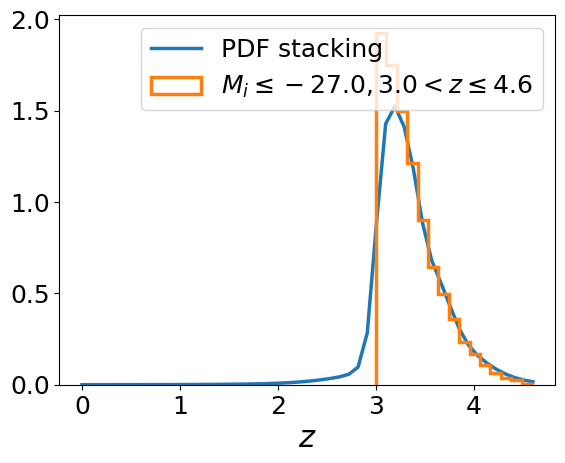

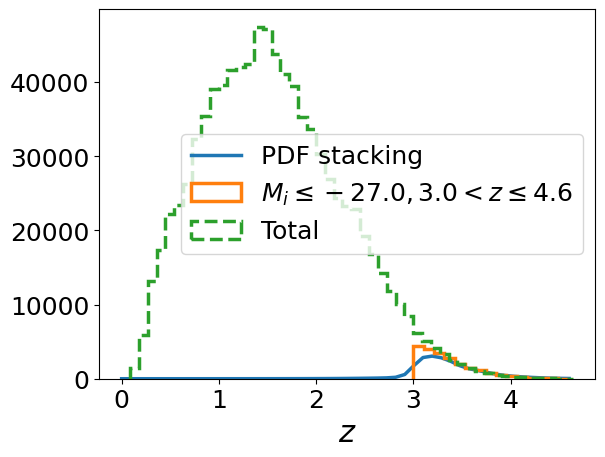

In [86]:
plt.plot(dz, dN_dz/norm, label = 'PDF stacking', linewidth = 2.5)
plt.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '$M_i\leq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), histtype = 'step', linewidth = 2.5, density = True, bins = 15)
plt.legend()
plt.xlabel('$z$')
plt.show()

plt.plot(dz, dN_dz*np.diff(dz)[0], label = 'PDF stacking', linewidth = 2.5)
plt.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '$M_i\leq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), histtype = 'step', linewidth = 2.5, bins = 15)
plt.hist(tab_datahi_mask['redshift_quaia'], label = 'Total', histtype = 'step', linewidth = 2.5, bins = 50, linestyle = '--')
plt.legend()
plt.xlabel('$z$')
plt.show()

In [87]:
diag = False #True # False

In [88]:
# Define our 3-D correlated multivariate normal log-likelihood.
C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
if diag == True:
    C*=np.identity(len(C))
# ix_grid = np.ix_(np.full(np.shape(wp_zbin_i), True), np.full(np.shape(wp_zbin_i), True))
ix_grid = np.ix_(theta_mask, theta_mask)
hartlap = (N-nbins-2)/(N-1)
print(hartlap)

def log_det(C, ix_grid):  
    
    # check if cov is hermitian and positive definite
    if linalg.ishermitian(C[ix_grid]) and np.all(np.linalg.eigvals(C[ix_grid]) > 0):
        C_factor = linalg.cho_factor(C[ix_grid])
        log_det_C = 2 * np.sum(np.log(np.diag(C_factor[0])))
        solve = lambda rhs: linalg.cho_solve(C_factor, rhs)
    else:
        print('using LU decomposition')
        C_factor = linalg.lu_factor(C[ix_grid])
        log_det_C = np.sum(np.log(np.abs(np.diag(C_factor[0])))) # does abs value make sense
        solve = lambda rhs: linalg.lu_solve(C_factor, rhs)

    return log_det_C, solve
        
log_det_C, solve = log_det(C, ix_grid)

def loglike(x, log_det_C, wp, nbins, solve, dN_dz, theta_mask = theta_mask, M_max = M_max, N = N, fduty = 0, optimize = False):
    
    M_min = x[0]
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*10**fduty

    if optimize == True:
        wp_2h_zbin = wtheta_2h_optimized(bins_m, n_m, dN_dz, theta_mask = theta_mask)
    else:
        wp_2h_zbin, _ = wtheta_2h(bins_m, n_m, dN_dz, theta_mask = theta_mask)
    delta = wp-wp_2h_zbin
    
    c_p = gamma(N/2)/((np.pi*(N-1))**(nbins/2)*gamma((N-nbins)/2))
    lnorm = np.log(c_p)-0.5*log_det_C  

    return -N*0.5 * np.log(1+(delta.T @ solve(delta))/(N-1)) + lnorm #- penalty

0.3673469387755102


In [89]:
def ptform(u):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u 

    # Uniform from 9 to 15
    x[0] = 7 * u[0] + 9  # scale and shift to [9., 16.)

    return x

In [90]:
nlive = 500 #3000 #500
dlogz = 0.01

In [91]:
nbins_mask = np.sum(theta_mask)
nbins, np.sum(theta_mask), len(wp_chi2[L_bins[i]][j][theta_mask]), len(wp_chi2[L_bins[i]][j])

(30, 16, 16, 30)

In [92]:
L_array2 = np.array([-32.0, -27.0, -26.0, -25.0, -20.0])
L_bins2 = L_array2[:0:-1]
L_bins2

array([-20., -25., -26., -27.])

In [93]:
x_test = np.array([12.0])  # test M_min
start = time.time()
# result = loglike(x_test, log_det_C, wp_chi2[L_bins[i]][j][theta_mask], np.sum(theta_mask), solve, dN_dz/norm, theta_mask=theta_mask)
result = loglike(x_test, log_det_C, wp_chi2[L_bins[i]][j][theta_mask], nbins_mask, solve, H0_c_dN_dz, theta_mask=theta_mask, optimize = True)
print(f"Time: {time.time()-start:.2f}s")

print(result)

Time: 0.03s
16.919352186395322


In [94]:
# initialize our nested sampler
# sampler = NestedSampler(loglike, ptform, ndim, logl_args=[log_det_C, wp_chi2[L_bins[i]][j][theta_mask], np.sum(theta_mask), solve, dN_dz/norm], 
#                         nlive = nlive, logl_kwargs = {'theta_mask': theta_mask})
sampler = NestedSampler(loglike, ptform, ndim, logl_args=[log_det_C, wp_chi2[L_bins[i]][j][theta_mask], nbins_mask, solve, H0_c_dN_dz], 
                        nlive = nlive, logl_kwargs = {'theta_mask': theta_mask, 'optimize': True})

In [ ]:
# run the sampler with checkpointing
sampler.run_nested(dlogz = dlogz)
results = sampler.results

1543it [04:21,  1.90it/s, bound: 0 | nc: 9 | ncall: 10737 | eff(%): 14.371 | loglstar:   -inf < 17.071 <    inf | logz: 15.389 +/-  0.042 | dlogz:  0.238 >  0.010]  

In [ ]:
# Print out a summary of the results.
results.summary()

In [ ]:
fig, axes = dyplot.runplot(results)  # summary (run) plot
fig.subplots_adjust(hspace=0.25)
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)

In [ ]:
labels = [r'$\log_{10} M_\mathrm{min}$']
fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=labels)
fig.subplots_adjust(hspace=0.6)
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1.1)

In [ ]:
# # initialize figure
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# plot initial run (res1; left)
fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                           truth_color='black', show_titles=True,
                           max_n_ticks=3, quantiles=[0.025, 0.5, 0.975], labels=labels, fig=(fig, axes))
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1.05, x = 0.6)

In [ ]:
samples, weights = results.samples, results.importance_weights()
mean, cov = dyfunc.mean_and_cov(samples, weights)
print(mean, cov)

In [ ]:
# Compute weighted quantiles
# samples, weights = results.samples, results.importance_weights()

# Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
quantiles = [dyfunc.quantile(samples[:, i], [0.16, 0.5, 0.84], weights=weights) 
             for i in range(samples.shape[1])]
# labels = ['log10(M_min)']

for i, (lo, mid, hi) in enumerate(quantiles):
    print(f"{labels[i]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")

In [ ]:
equal_weight_samples = dyfunc.resample_equal(samples, weights)

## Try fitting $f_{duty}$

In [ ]:
labels_fduty = [r'$\log_{10} f_\mathrm{duty}$']

In [ ]:
bins_m = np.logspace(equal_weight_samples, M_max, 79)
n_m=np.ones(len(bins_m))

n_dm = []
for k in range(len(equal_weight_samples)):
    n_dm.append(M(bins_m[:,k][:,0], n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1])
equal_weight_samples_fduty = np.log10(n_q[L_bins[i]][j]/n_dm)

In [ ]:
# Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
lo, mid, hi = dyfunc.quantile(equal_weight_samples_fduty, [0.16, 0.5, 0.84]) 

# for i, (lo, mid, hi) in enumerate(quantiles):
print(f"{labels_fduty[0]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")

In [ ]:
results_fduty = Results({
    'samples': equal_weight_samples_fduty,
    'logwt': results['logwt'],          # equal weights -> uniform log weights
    'logz': np.array([0.0]),
    'logzerr': np.array([0.0]),
    'logl': results['logl'],
    'nlive': nlive,
    'samples_u': results['samples_u'],
    'samples_id': results['samples_id']
})

In [ ]:
# # initialize figure
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# plot initial run (res1; left)
fg, ax = dyplot.cornerplot(results_fduty, color='blue', show_titles=True,
                           max_n_ticks=3, quantiles=[0.025, 0.5, 0.975], labels=labels_fduty, fig=(fig, axes))
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1.05, x = 0.6)

## Across all $z$

In [ ]:
dN_dz_norm, H0_c_dN_dz_norm = {L: [] for L in L_bins}, {L: [] for L in L_bins}
for i in range(len(L_bins)):
    for j in z_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0, _, _ = quaia.make_bins(
            G_hi, [j, i], True, ['z', 'L'], bins = [z_bins, L_bins], tab_gcat_type = 'data', method = ['minmax', 'max'], fac_rand = fac_rand, 
            n_bins = [None, None], b = b, mask_type = 'b', verbose = False)
        
        dN_dz = np.sum(stats.norm.pdf(dz[None, :], loc=tab_datahi_mask_zbin0['redshift_quaia'][:, None], scale=tab_datahi_mask_zbin0['redshift_quaia_err'][:, None]), axis = 0)
        dN_dz /= np.sum(stats.norm.cdf(dz[-1], loc=tab_datahi_mask_zbin0['redshift_quaia'], scale=tab_datahi_mask_zbin0['redshift_quaia_err']))
        
        dN_dz_norm[L_bins[i]].append(dN_dz)
        H0_c_dN_dz_norm[L_bins[i]].append([ccl.background.h_over_h0(cosmo_planck18, 1/(1+dz[k]))*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*
                                      dN_dz[k]**2 for k in range(len(dz))])

In [ ]:
f_duty, M_min = {L: [] for L in L_bins}, {L: [] for L in L_bins}
err_labels = ['log10(f_duty)', 'log10(M_min)']
err = {i: {L: [] for L in L_bins} for i in err_labels}
f_duty_samples, M_min_samples = {L: [] for L in L_bins}, {L: [] for L in L_bins}
best_fit_params = {L: [] for L in L_bins}
equal_weight_samples = {L: [] for L in L_bins}
results_Mmin = {L: [] for L in L_bins}

for i in range(len(L_bins)):

    print('M_i<={}'.format(L_bins[i]))

    for j in z_array:

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            if diag == True:
                C*=np.identity(len(C))
            # ix_grid = np.ix_(rpmask[L_bins[i]][j], rpmask[L_bins[i]][j])
    
            log_det_C, solve = log_det(C, ix_grid)
            
            # initialize our nested sampler
            # sampler = NestedSampler(loglike, ptform, ndim, loglike, ptform, ndim, 
            #                         logl_args=[log_det_C, wp_chi2[L_bins[i]][j][theta_mask], np.sum(theta_mask), solve, dN_dz_norm[L_bins[i]][j]],
            #                         nlive = nlive, logl_kwargs = {'theta_mask': theta_mask}, rstate=np.random.default_rng(0))
            sampler = NestedSampler(loglike, ptform, ndim, logl_args=[log_det_C, wp_chi2[L_bins[i]][j][theta_mask], nbins_mask, solve, 
                                                                      H0_c_dN_dz_norm[L_bins[i]][j]], nlive = nlive, 
                                    logl_kwargs = {'theta_mask': theta_mask, 'optimize': True}, rstate=np.random.default_rng(0))
            
            # run the sampler with checkpointing
            sampler.run_nested(dlogz = dlogz)
            results = sampler.results
            
            # Print out a summary of the results.
            results.summary()
            
            fig, axes = dyplot.runplot(results)  # summary (run) plot
            fig.subplots_adjust(hspace=0.25)
            fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)
            
            fig, axes = dyplot.traceplot(results, 
                                     show_titles=True,
                                     trace_cmap='viridis', connect=True,
                                     connect_highlight=range(5), labels=labels)
            fig.subplots_adjust(hspace=0.6)
            fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1.1)
            
            # initialize figure
            fig, axes = plt.subplots(1, 1, figsize=(5, 5))
        
            # plot initial run (res1; left)
            fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                                       truth_color='black', show_titles=True,
                                       max_n_ticks=3, quantiles=None, labels=labels, fig=(fig, axes))
            fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1.05, x = 0.6)    
            
            samples, weights = results.samples, results.importance_weights()
        
            # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
            quantiles = [dyfunc.quantile(samples[:, i], [0.16, 0.5, 0.84], weights=weights) 
                         for i in range(samples.shape[1])]
        
            print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))
            for k, (lo, mid, hi) in enumerate(quantiles):
                k = -1
                print(f"{err_labels[k]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")
                err[err_labels[k]][L_bins[i]].append((lo, hi))
            print()
            
            equal_weight_samples[L_bins[i]].append(dyfunc.resample_equal(samples, weights))
            ind = np.random.choice(range(len(equal_weight_samples[L_bins[i]][j])), size = 1000, replace = False)

            M_min_sample = equal_weight_samples[L_bins[i]][j][ind][:,0]
            
            M_min_median = quantiles[0][1]
            
            # Get the maximum likelihood sample from dynesty results
            idx_max = np.argmax(results.logl)
            best_fit_param = samples[idx_max]
        
        else:

            equal_weight_samples[L_bins[i]].append(np.nan)
            
            M_min_sample = [np.nan]*1000
            
            M_min_median = np.nan

            err[err_labels[-1]][L_bins[i]].append((np.nan, np.nan))

            best_fit_param = [np.nan]*ndim

            results = np.nan
            
        M_min_samples[L_bins[i]].append(M_min_sample)
        
        M_min[L_bins[i]].append(M_min_median) 

        # Get the maximum likelihood sample from dynesty results
        best_fit_params[L_bins[i]].append(best_fit_param)

        results_Mmin[L_bins[i]].append(results)

In [ ]:
cmap_purple = plt.get_cmap('Purples')(np.linspace(0.333, 0.999, len(z_array)))

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (35, 35))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)

for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            ax1 = fig.add_subplot(gs[j*4+i])

            # --- corner plot -> buffer -> master cell ---
            fg, ax = dyplot.cornerplot(results_Mmin[L_bins[i]][j], color=cmap_purple[::-1][i], show_titles=False, quantiles=[0.16,0.5,0.84],
                                       fig=(fig, ax1), labels = ['$\log_{10}(M_\mathrm{min}/M_\odot)$'])#, 
            
            lines=ax1.get_lines()
            for line in lines:
                line.set_linewidth(2.5)
            lines[0].set_linestyle('--')
            lines[1].set_linestyle('-')
            lines[2].set_linestyle('--')
            ylim=ax1.get_ylim()

            ax1.set_xlim(9, 14)
            # titles & labels
            if j==0 or ((j == 1) and (i == 3)):
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                ax1.set_ylabel(r"${:.1f}<z\leq{:.1f}$".format(
                    z_bins[j], z_bins[j+1]))
            plt.setp(ax1.get_xticklabels(), rotation=0, ha='center')
            # ... rest of your existing sample/quantile code ...

            samples, weights = results_Mmin[L_bins[i]][j].samples, results_Mmin[L_bins[i]][j].importance_weights()

            # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
            quantiles = [dyfunc.quantile(samples[:, k], [0.16, 0.5, 0.84], weights=weights) 
                         for k in range(samples.shape[1])]
            
            for k, (lo, mid, hi) in enumerate(quantiles):
                legend = f"${mid:.2f}^{{+{hi-mid:.2f}}}_{{-{mid-lo:.2f}}}$"

            custom_lines = [Line2D([0], [0], color = cmap_purple[::-1][i], linestyle = '-', linewidth=2.5)]
            ax1.legend(handles=custom_lines, labels=[legend])
            ax1.xaxis.set_label_coords(0.5, -0.1)
            
fig.savefig('../figures/cornerplot_Mmin_b{}_wtheta.pdf'.format(b), bbox_inches='tight')
plt.show()

In [ ]:
f_duty = {L: [] for L in L_bins}
f_duty_samples = {L: [] for L in L_bins}

for i in range(len(L_bins)):

    print('M_i<={}'.format(L_bins[i]))
    
    for j in z_array:

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):
        
            print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))            
            bins_m = np.logspace(equal_weight_samples[L_bins[i]][j][:,0], M_max, 79) #M_min_samples
            n_m=np.ones(len(bins_m))
            
            n_dm = [M(bins_m[:,k], n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1] for k in range(len(equal_weight_samples[L_bins[i]][j]))]
            equal_weight_samples_fduty = np.log10(n_q[L_bins[i]][j]/n_dm)

            # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
            lo, mid, hi = dyfunc.quantile(equal_weight_samples_fduty, [0.16, 0.5, 0.84]) 
            
            print(f"{labels_fduty[0]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}\n")
            err[err_labels[0]][L_bins[i]].append((lo, hi))

            f_duty_median = mid

            ind = np.random.choice(range(len(equal_weight_samples_fduty)), size = 1000, replace = False)
            f_duty_sample = equal_weight_samples_fduty[ind]

            # # Get the maximum likelihood sample from dynesty results
            bins_m = np.logspace(best_fit_params[L_bins[i]][j][0], M_max, 79)
            n_dm = M(bins_m, n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1]
            best_fit_param = np.log10(n_q[L_bins[i]][j]/n_dm)

            # results_fduty = Results({
            #     'samples': equal_weight_samples_fduty,
            #     'logwt': results_Mmin[L_bins[i]][j]['logwt'],          # equal weights -> uniform log weights
            #     'logz': np.array([0.0]),
            #     'logzerr': np.array([0.0]),
            #     'logl': results_Mmin[L_bins[i]][j]['logl'],
            #     'nlive': nlive,
            #     'samples_u': results_Mmin[L_bins[i]][j]['samples_u'],
            #     'samples_id': results_Mmin[L_bins[i]][j]['samples_id']
            # })
            
            # # # initialize figure
            # fig, axes = plt.subplots(1, 1, figsize=(5, 5))
            
            # # plot initial run (res1; left)
            # fg, ax = dyplot.cornerplot(results_fduty, color='blue', show_titles=True,
            #                            max_n_ticks=3, quantiles=[0.025, 0.5, 0.975], labels=labels_fduty, fig=(fig, axes))
            # fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[j], z_bins[i], z_bins[i+1]), fontsize = 20, y = 1.05, x = 0.6)
            
        else:

            f_duty_sample = [np.nan]*1000
            
            f_duty_median = np.nan

            err[err_labels[0]][L_bins[i]].append((np.nan, np.nan))

            best_fit_param = [np.nan]*ndim
            
        f_duty_samples[L_bins[i]].append(f_duty_sample)
        
        f_duty[L_bins[i]].append(f_duty_median)

        # Get the maximum likelihood sample from dynesty results
        # idx_max = np.argmax(results.logl)
        best_fit_params[L_bins[i]][j]=np.append(best_fit_param, best_fit_params[L_bins[i]][j])

### Solve for $\chi_c^2=\Delta^T x$ where $Cx=\Delta$

In [ ]:
def f0_GLS_solve(x, a, C, wp, dN_dz_norm, cosmo = cosmo_planck18, rpmask = True, hartlap = hartlap, fduty = 0, M_max = M_max):
    
    M_min = x[0]
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*10**fduty
        
    # wp_2h_zbin, b_q = wp_2h(bins_m, n_m, a, cosmo, wp_matter, rpbins = rpbins, pibins = pibins, recenter = False)
    wp_2h_zbin, b_q = wtheta_2h(bins_m, n_m, dN_dz_norm)
    
    if isinstance(rpmask, bool):
        rpmask = [rpmask]*len(quaia.recenter(rpbins))
    delta = (wp-wp_2h_zbin)[rpmask]
    ix_grid = np.ix_(rpmask, rpmask)
    
    return delta.T @ (hartlap*np.linalg.solve(C[ix_grid], delta))

### Add a number density constraint

In [ ]:
def constraint(x, a, n_q, cosmo = cosmo_planck18, error = 0.05, M_max = M_max, fduty = 0):
    
    M_min = x[0]
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*10**fduty
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]

    return error-np.abs(n_q_theory-n_q)/n_q

In [ ]:
for i in range(len(L_bins)):

    print('M_i<={}'.format(L_bins[i]))

    for j in z_array:
        
        print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))
        x = [M_min[L_bins[i]][j]]
        
        C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
        if diag == True:
            C*=np.identity(len(C))
        chi2 = f0_GLS_solve(x, a_zbin[L_bins[i]][j], C, wp_chi2[L_bins[i]][j], dN_dz_norm[L_bins[i]][j], rpmask = theta_mask, 
                            fduty = f_duty[L_bins[i]][j])
        df = nbins_mask-len(x)-1
    
        print('           chi^2: {:.2f}'.format(chi2))
        print('   reduced chi^2: {:.2f}'.format(chi2/df))
        print('         delta n: {:.2e}'.format(constraint(x, a_zbin[L_bins[i]][j], n_q[L_bins[i]][j], fduty = f_duty[L_bins[i]][j])))
        try:
            print('condition number: {:.2f}'.format(np.linalg.cond(C[ix_grid])))
        except Exception as e:
            print(e)
        print('             PTE: {:.2f}\n'.format(stats.chi2.sf(chi2, df)))

## Plot results

In [ ]:
z_eff = [0.5, 1.5, 2.5, 3.5]

In [ ]:
M_min_err_hi = [0.04, 0.02, 0.03, 0.1]
M_min_err_lo = [0.05, 0.02, 0.03, 0.12]

In [ ]:
cmap_grey = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, len(L_bins)))

In [ ]:
M_min_array_old = [12.86, 12.74, 12.79, 12.82]

In [ ]:
zmin, zmax = [], []
for i in range(len(L_bins)):
    
    zmin.append(np.min(1/np.array(a_zbin[L_bins[i]])-1))
    zmax.append(np.max(1/np.array(a_zbin[L_bins[i]])-1))

zmin = np.max(zmin)
zmax = np.min(zmax)
zmin, zmax

In [ ]:
cmap_green = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))

In [ ]:
blue = np.mean(cmap_blue, axis = 0)
green = np.mean(cmap_green, axis = 0)
purple = np.mean(cmap_purple, axis = 0)
orange = np.mean(cmap_orange, axis = 0)

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in range(len(L_bins)):
    
    M_min_lo, M_min_hi = np.array(err['log10(M_min)'][L_bins[i]])[:,0], np.array(err['log10(M_min)'][L_bins[i]])[:,1]
    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    plt.plot(zbin, M_min[L_bins[i]], color = cmap_purple[::-1][i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)', zorder = 0)
    plt.fill_between(zbin, M_min_lo, M_min_hi, alpha = 0.5, color = cmap_purple[::-1][i])

    # plt.plot(zbin, np.array(best_fit_params[L_bins[i]]).T[1], color = cmap_orange[::-1][i], linewidth = 2.5, label = 'max chi$^2$', linestyle = '--')
    
plt.title(r'$w(\theta)$')#, N_{{jk}}={}$, step-function, sellentin'.format(N))
plt.plot(z_eff, M_min_array, label = 'Giner Mascarell et al. 2025', color = cmap_red[-1], linewidth = 2.5, linestyle = '--', zorder = 3)
plt.fill_between(z_eff, M_min_array+np.array(M_min_array)/M_min_array_old*M_min_err_hi, 
                 M_min_array-np.array(M_min_array)/M_min_array_old*M_min_err_lo, alpha = 0.5, color = cmap_red[-1])
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.xlim(zmin, zmax)
# plt.ylim(9,15)

custom_lines = [Line2D([0], [0], color = purple, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = cmap_red[-1], linestyle = '--', linewidth = 2.5)]
                # Line2D([0], [0], color = orange, linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
                                          'Giner Mascarell et al. 2025'],
                           # , 'max chi$^2$'], 
                           loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_purple[::-1][i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = plt.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])
fig.add_artist(first_legend)

plt.show()

In [ ]:
red = np.mean(cmap_red, axis = 0)

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in z_array:
    
    M_min_lo, M_min_hi = [np.array(err['log10(M_min)'][L])[:,0][i] for L in L_bins], [np.array(err['log10(M_min)'][L])[:,1][i] for L in L_bins]
    plt.plot(L_bins, [M_min[L][i] for L in L_bins], color = cmap_purple[i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
    plt.fill_between(L_bins, M_min_lo, M_min_hi, alpha = 0.5, color = cmap_purple[i])
    plt.axhline(M_min_array[i], label = 'Giner Mascarell et al. 2025', color = cmap_red[i], linewidth = 2.5, linestyle = '--')
    plt.fill_between(L_bins, [M_min_array[i]+(np.array(M_min_array)/M_min_array_old*M_min_err_hi)[i]]*len(L_bins), [M_min_array[i]-(np.array(M_min_array)/M_min_array_old*M_min_err_lo)[i]]*len(L_bins), alpha = 0.5, color = cmap_red[i])
    plt.plot(L_bins, [best_fit_params[L][i][1] for L in L_bins], color = cmap_orange[i], linewidth = 2.5, label = 'max chi$^2$', linestyle = '--')
    
plt.title(r'$w(\theta), N_{{jk}}={}$, step-function, sellentin'.format(N))
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$M_i$')
plt.xlim(L_bins[0], L_bins[-1])
plt.ylim(10.95,14.75)

custom_lines = [Line2D([0], [0], color = purple, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = red, linestyle = '--', linewidth = 2.5),
                Line2D([0], [0], color = orange, linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
                                          'Giner Mascarell et al. 2025', 'max chi$^2$'], loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_grey[i], alpha = 0.5) for i in range(len(z_array))]
first_legend = plt.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]) for i in z_array])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fduty_old = [0.018, 0.022, 0.056, 0.071]

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in range(len(L_bins)):
    
    f_duty_lo, f_duty_hi = np.array(err['log10(f_duty)'][L_bins[i]])[:,0], np.array(err['log10(f_duty)'][L_bins[i]])[:,1]
    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    plt.plot(zbin, f_duty[L_bins[i]], color = cmap_purple[::-1][i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
    plt.fill_between(zbin, f_duty_lo, f_duty_hi, alpha = 0.5, color = cmap_purple[::-1][i])
    plt.plot(zbin, np.array(best_fit_params[L_bins[i]]).T[0], color = cmap_orange[::-1][i], linewidth = 2.5, label = 'max chi$^2$', linestyle = '--')
   
plt.title(r'$w(\theta)$')#, N_{{jk}}={}$, step-function, sellentin'.format(N))
plt.plot(z_eff, np.log10(fduty), label = 'Giner Mascarell et al. 2025', color = cmap_red[-1], linewidth = 2.5, linestyle = '--')
plt.fill_between(z_eff, np.log10(np.array(fduty)+np.array(fduty)/fduty_old*fduty_err_hi), 
                 np.log10(np.array(fduty)-np.array(fduty)/fduty_old*fduty_err_lo), alpha = 0.5, color = cmap_red[-1])
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.xlim(zmin, zmax)
plt.ylim(-6,0)

custom_lines = [Line2D([0], [0], color = purple, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = cmap_red[-1], linestyle = '--', linewidth = 2.5),
                Line2D([0], [0], color = orange, linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
                                          'Giner Mascarell et al. 2025', 'max chi$^2$'], loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_grey[::-1][i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = plt.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in z_array:
    
    f_duty_lo, f_duty_hi = [np.array(err['log10(f_duty)'][L])[:,0][i] for L in L_bins], [np.array(err['log10(f_duty)'][L])[:,1][i] for L in L_bins]
    plt.plot(L_bins, [f_duty[L][i] for L in L_bins], color = cmap_purple[i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
    plt.fill_between(L_bins, f_duty_lo, f_duty_hi, alpha = 0.5, color = cmap_purple[i])
    plt.axhline(np.log10(fduty)[i], label = 'Giner Mascarell et al. 2025', color = cmap_red[i], linewidth = 2.5, linestyle = '--')
    plt.fill_between(L_bins, [np.log10(np.array(fduty)+np.array(fduty)/fduty_old*fduty_err_hi)[i]]*len(L_bins), 
                     [np.log10(np.array(fduty)-np.array(fduty)/fduty_old*fduty_err_lo)[i]]*len(L_bins), alpha = 0.5, color = cmap_red[i])
    plt.plot(L_bins, [best_fit_params[L][i][0] for L in L_bins], color = cmap_orange[i], linewidth = 2.5, label = 'max chi$^2$', linestyle = '--')
    
plt.title(r'$w(\theta), N_{{jk}}={}$, step-function, sellentin'.format(N))
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$M_i$')
plt.xlim(L_bins[0], L_bins[-1])
plt.ylim(-4.75,0)

custom_lines = [Line2D([0], [0], color = purple, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = red, linestyle = '--', linewidth = 2.5),
                Line2D([0], [0], color = orange, linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
                                          'Giner Mascarell et al. 2025', 'max chi$^2$'], loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_grey[i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = plt.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]) for i in z_array], loc = 'lower left')
fig.add_artist(first_legend)

plt.show()

## Calculate 16th and 84th percentile of derived parameters

In [ ]:
cmap_purple = plt.get_cmap('Purples')(np.linspace(0.333, 0.999, len(L_bins)))

In [ ]:
cmap_rocket = sns.color_palette("flare_r", n_colors = len(L_bins))
cmap_rocket

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)
# r = quaia.recenter(rbins_offset)
xlim = 10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + 5/2*delta_xlim) 
ylim = 1e-5, 2e2
y = np.linspace(ylim[0], ylim[-1])

for j in z_array:
    
    ax1 = fig.add_subplot(gs[j])

    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            
            ax1.errorbar(10**(np.log10(quaia.recenter(thetabins)) + i*delta_xlim/2), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
                         label = r'Quaia', color = cmap_theta[i], yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = '-')
            
            wp_2h_samples=[]
            for l in range(len(ind)):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])

            ax1.plot(quaia.recenter(thetabins), wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_purple[::-1][i])
            ax1.fill_between(quaia.recenter(thetabins), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_purple[::-1][i])
            
    if quaia.recenter(thetabins)[-1] > 1:
        ax1.fill_betweenx(y, x1 = xlim[0], x2 = 2e-3, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                          alpha = 0.5)

    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
    ax1.set_yscale('log')
    ax1.set_xlim(xlim)
    ax1.set_ylim(ylim)
    
    if j%2==0:
        ax1.set_ylabel(r'$w(\theta)$')
    else:
        ax1.set_yticklabels([])

    if j>1:
        ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

custom_lines = [mpatches.Patch(color=cmap_grey[::-1][l], alpha = 0.5) for l in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))], loc = 'lower left')
fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_red, axis = 0), linestyle = '-', marker = 'o', linewidth = 2.5, markeredgewidth = 2.5),
                Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5), mpatches.Patch(color='grey', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'Quaia', r'Shiferaw et al. 2026 (this work)', 'scales excluded from fit'], loc = 'upper right')
fig.add_artist(second_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)
# ylim = 2e-4, 4e2
# y = np.linspace(ylim[0], ylim[-1])

for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i])

    for j in z_array:

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            
            ax1.errorbar(10**(np.log10(quaia.recenter(thetabins)) + i*delta_xlim/2), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
                         label = r'Quaia', color = cmap_theta[i], yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = '-')
            
            wp_2h_samples=[]
            for l in range(len(ind)):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

            ax1.plot(quaia.recenter(thetabins), wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_purple[j])
            ax1.fill_between(quaia.recenter(rbins_offset), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_purple[j])
            
    if quaia.recenter(thetabins)[-1] > 1:
        ax1.fill_betweenx(y, x1 = xlim[0], x2 = 2e-3, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                          alpha = 0.5)

    ax1.set_title(r'$M_i\leq{}$'.format(L_bins[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(xlim)
    ax1.set_ylim(ylim)
    
    if i%2==0:
        ax1.set_ylabel(r'$w(\theta)$')
    else:
        ax1.set_yticklabels([])

    if i>1:
        ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

    if i ==0:
        custom_lines = [mpatches.Patch(color=cmap_grey[l], alpha = 0.5) for l in range(len(L_bins))]
        first_legend = ax1.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[l], z_bins[l+1]) for l in z_array])
        fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_rocket, axis = 0), linestyle = '-', marker = 'o', linewidth = 2.5, markeredgewidth = 2.5),
                Line2D([0], [0], color = np.mean(cmap_purple, axis = 0), linestyle = '-', linewidth = 2.5), mpatches.Patch(color='grey', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'Quaia', r'Shiferaw et al. 2026 (this work)', 'scales excluded from fit'])
fig.add_artist(second_legend)

plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)
# ylims = [[-0.75, 2.5], [-2.5, 12.5], [-12.5, 50], [-75, 375]], [[-0.5, 2.5], [-0.5, 2.5], [-0.5, 7.5], [-2.5, 25]], [[np.nan, np.nan], [-1, 2.75], [-0.75, 5], [-2.5, 10]], [[np.nan, np.nan], [np.nan, np.nan], [-10, 12.5], [-25, 25]]
# r = quaia.recenter(rbins_chi2)
# xlim = r[0]-np.diff(r)[0]/2, r[-1]+np.diff(r)[0]/2

for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            ax1 = fig.add_subplot(gs[j*4+i])

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            
            ax1.errorbar(quaia.recenter(thetabins), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
                         label = r'Quaia', color = cmap_theta[i], yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = 'none')
            
            if quaia.recenter(thetabins)[-1] > 1:
                ax1.fill_betweenx(y, x1 = xlim[0], x2 = 2e-3, color = 'grey', 
                              alpha = 0.5, label = 'scales excluded from fit')
                ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                                  alpha = 0.5)
        
            # plot new fit
            n_m=np.ones(np.shape(bins))*10**f_duty[L_bins[i]][j]
            wp_2h_zbin = wtheta_2h_optimized(np.logspace(M_min[L_bins[i]][j],M_max,79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
            ax1.plot(quaia.recenter(rbins_chi2), wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_purple[::-1][i])
        
            wp_2h_samples = []
            for l in range(len(ind)):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

            ax1.fill_between(quaia.recenter(rbins_chi2), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
                     color = cmap_purple[::-1][i])  

            #maxL point
            n_m=np.ones(np.shape(bins))*10**best_fit_params[L_bins[i]][j][0]
            wp_2h_zbin, b_q = wtheta_2h_optimized(np.logspace(best_fit_params[L_bins[i]][j][1],M_max,79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
            ax1.plot(quaia.recenter(rbins_chi2), wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$)'.format(best_fit_params[L_bins[i]][j][0], best_fit_params[L_bins[i]][j][1]), 
                     color = 'orange')
        
            if j==0 or ((j == 1) and (i == 3)):
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_xlim(xlim)
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))
        
            if j > 2 or ((j>0) and (i<2) and (i!=j)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)
# ylim = 2e-4, 4e2

for i in range(len(L_bins)):

    for j in range(len(z_array)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            ax1 = fig.add_subplot(gs[i*4+j])

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
                   
            ax1.errorbar(quaia.recenter(thetabins), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
                         label = r'Quaia', color = cmap_theta[i], yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = 'none')
            if quaia.recenter(thetabins)[-1] > 1:
                ax1.fill_betweenx(y, x1 = xlim[0], x2 = 2e-3, color = 'grey', 
                              alpha = 0.5, label = 'scales excluded from fit')
                ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                                  alpha = 0.5)
        
            wp_2h_samples = []
            for l in range(len(ind)):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

            ax1.plot(quaia.recenter(thetabins), wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_purple[j])
            ax1.fill_between(quaia.recenter(rbins_chi2), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
                     color = cmap_purple[j])    
        
            if i ==0 or ((i<3) and (j>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
            ax1.set_xlim(xlim)
            ax1.legend()
            
            if j==0:
                ax1.set_ylabel(r"$w_{{p,M_i\leq{}}}(\theta)$".format(L_bins[i]))
        
            if i > 2 or ((i == 2) and (j == 0)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') 
            ax1.set_ylim(ylim)

plt.show()

In [ ]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (41, 32))
gs = gridspec.GridSpec(4, 6, wspace = 0, hspace = 0.1, width_ratios = [1,1,1,1,0.05,0.05])

l = 0
for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        ax1 = fig.add_subplot(gs[j*4+i+l])

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):
            
            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))

            if quaia.recenter(thetabins)[-1] > 1:
                ax1.fill_betweenx(y, x1 = xlim[0], x2 = 2e-3, color = 'grey', 
                              alpha = 0.5, label = 'scales excluded from fit')
                ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                                  alpha = 0.5)
        
            for k in range(len(bins)):
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min[L_bins[i]][j]-1+k/int(len(bins)/2), M_max, 79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                ax1.plot(quaia.recenter(thetabins), wp_2h_sample, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
                
            wp_2h_samples = []
            for k in range(len(ind)):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][k],M_max,79), M_max, 79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            
            ax1.plot(quaia.recenter(thetabins), wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_purple[::-1][i])
            ax1.fill_between(quaia.recenter(thetabins), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
                     color = cmap_purple[::-1][i])    
            
            if j==0 or ((j == 1) and (i == 3)):
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_yscale('log')
            ax1.set_xlim(xlim)
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))
            else:
                ax1.set_yticklabels([])
        
            if j > 2 or ((j>0) and (i<2) and (i!=j)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') 

        else:

            ax1.set_axis_off()
            
        if i == 3:
            l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (41, 32))
gs = gridspec.GridSpec(4, 6, wspace = 0, hspace = 0.1, width_ratios = [1,1,1,1,0.05,0.05])

l = 0
for i in range(len(L_bins)):

    for j in range(len(z_array)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            ax1 = fig.add_subplot(gs[i*4+j+l])
            
            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))


            if quaia.recenter(thetabins)[-1] > 1:
                ax1.fill_betweenx(y, x1 = xlim[0], x2 = 2e-3, color = 'grey', 
                              alpha = 0.5, label = 'scales excluded from fit')
                ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                                  alpha = 0.5)
        
            for k in range(len(bins)):
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min[L_bins[i]][j]-1+k/int(len(bins)/2), M_max, 79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                ax1.plot(quaia.recenter(rbins_chi2), wp_2h_sample, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
                
            wp_2h_samples = []
            for k in range(len(ind)):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][k],M_max,79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

            ax1.plot(quaia.recenter(thetabins), wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_purple[j])
            ax1.fill_between(quaia.recenter(thetabins), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
                     color = cmap_purple[j])    
            
            if i ==0 or ((i<3) and (j>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
            ax1.set_yscale('log')
            ax1.set_xlim(xlim)
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if j==0:
                ax1.set_ylabel(r"$w_{{M_i\leq{}}}(\theta)$".format(L_bins[i]))
            else:
                ax1.set_yticklabels([])
        
            if i > 2 or ((i == 2) and (j == 0)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') 

        if j == 3:
            l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in range(len(L_bins)):
    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    b_q_percentile = []
    for j in z_array:
        b_q_samples=[]
        for k in range(len(ind)):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
            b_q_samples.append(wtheta_2h(np.logspace(M_min_samples[L_bins[i]][j][k],M_max,79), n_m, dN_dz_norm[L_bins[i]][j])[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 50, 84]))
    b_q_lo, b_q_mid, b_q_hi = np.array(b_q_percentile).T

    ax1.plot(zbin, b_q_mid, linewidth = 2.5, color = cmap_purple[::-1][i], label = '$M_i\leq{}$'.format(L_bins[i])) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_purple[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 8)
ax1.set_xlim(zmin, zmax)
ax1.set_ylabel(r'$b_q$')

ax1.legend()

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in z_array:
    b_q_percentile = []
    for j in range(len(L_bins)):
        b_q_samples=[]
        for k in range(len(ind)):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[j]][i][k]
            b_q_samples.append(wtheta_2h(np.logspace(M_min_samples[L_bins[j]][i][k],M_max,79), n_m, dN_dz_norm[L_bins[i]][j])[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 50, 84]))
    b_q_lo, b_q_mid, b_q_hi = np.array(b_q_percentile).T
    ax1.plot(L_bins, b_q_mid, linewidth = 2.5, color = cmap_purple[i], label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1])) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_purple[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$M_i$')
ax1.set_ylim(0, 10)
ax1.set_xlim(L_bins[0], L_bins[-1])
ax1.set_ylabel(r'$b_q$')

ax1.legend()

plt.show()

In [ ]:
fig = plt.figure(figsize = (21, 16))
gs = gridspec.GridSpec(2, 4, wspace = 0, hspace = 0.15, width_ratios = [1, 1, 0.05, 0.05])

l = 0
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i+l])

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    b_q = [wtheta_2h(bins_M_min[j], n_m_array[j], dN_dz_norm[L_bins[i]][j])[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_red[-1], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    b_q_percentile = []
    for j in z_array:
        b_q_samples=[]
        for k in range(len(ind)):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
            b_q_samples.append(wtheta_2h(np.logspace(M_min_samples[L_bins[i]][j][k],M_max,79), n_m, dN_dz_norm[L_bins[i]][j])[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 50, 84]))
    b_q_lo, b_q_mid, b_q_hi = np.array(b_q_percentile).T
    ax1.plot(zbin, b_q_mid, linewidth = 2.5, color = cmap_purple[::-1][i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_purple[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    for k in range(len(bins)):
        b_q = [wtheta_2h(np.logspace(M_min[L_bins[i]][j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*f_duty[L_bins[i]][j], dN_dz_norm[L_bins[i]][j])[1] for j in z_array]
        ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    ax1.plot(zbin, b_quaia(1.26, a_zbin[L_bins[i]]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(zbin, b_quaia(1.15, a_zbin[L_bins[i]]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
             color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761
    
    ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
    ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))

    if i > 1:
        ax1.set_xlabel('$z$')
    ax1.set_ylim(0, 10)
    ax1.set_xlim(zmin, zmax)
    if i %2==0:
        ax1.set_ylabel(r'$b_q$')
    else:
        ax1.set_yticklabels([])

    if i == 1:
        l+=2

custom_lines = [Line2D([0], [0], color = cmap_red[-1], linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = blue, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 4, bbox_to_anchor = (0, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (20.5, 16))
gs = gridspec.GridSpec(2, 3, wspace = 0.1, hspace = 0.15, width_ratios = [1, 1, 0.05])

l = 0
for i in z_array:

    ax1 = fig.add_subplot(gs[i+l])

    zbin = [1/np.array(a_zbin[L][i])-1 for L in L_bins]

    b_q = [wp_2h(bins_M_min[i], n_m_array[i], a_zbin[L][i], cosmo_planck18, wp_matter_chi2[L][i], 
                 recenter = False)[1] for L in L_bins]
    ax1.plot(L_bins, b_q, linewidth = 2.5, color = cmap_red[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    b_q_percentile = []
    for j in range(len(L_bins)):
        b_q_samples=[]
        for k in range(len(ind)):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[j]][i][k]
            b_q_samples.append(wtheta_2h(np.logspace(M_min_samples[L_bins[j]][i][k],M_max,79), n_m, dN_dz_norm[L_bins[i]][j])[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 50, 84]))
    b_q_lo, b_q_mid, b_q_hi = np.array(b_q_percentile).T
    ax1.plot(L_bins, b_q_mid, linewidth = 2.5, color = cmap_purple[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_purple[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    for k in range(len(bins)):
        b_q = [wtheta_2h(np.logspace(M_min[L][i]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*f_duty[L][i], dN_dz_norm[L_bins[i]][j])[1] for L in L_bins]
        ax1.plot(L_bins, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    ax1.plot(L_bins, b_quaia(1.26, [a_zbin[L][i] for L in L_bins]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(L_bins, b_quaia(1.15, [a_zbin[L][i] for L in L_bins]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(L_bins, b_eboss(np.array(zbin)), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
             color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761
    
    ax1.axhline(b_cf20[i], linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
    ax1.axhline(b_wp20[i], linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))

    if i > 1:
        ax1.set_xlabel('$M_i$')
    ax1.set_ylim(0, 10)
    ax1.set_xlim(L_bins[0], L_bins[-1])
    if i %2==0:
        ax1.set_ylabel(r'$b_q$')
    else:
        ax1.set_yticklabels([])

    if i == 1:
        l+=1

custom_lines = [Line2D([0], [0], color = red, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = blue, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 4, bbox_to_anchor = (0, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in range(len(L_bins)):

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = cmap_red[-1], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    M_h_percentile = []
    for j in z_array:
        M_h_samples=[]
        for k in range(len(ind)):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
            M_h_samples.append(M(np.logspace(M_min_samples[L_bins[i]][j][k], M_max, 79), n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, 
             recenter = False)[0])
        M_h_percentile.append(np.percentile(M_h_samples, [16, 50, 84]))
    M_h_lo, M_h_mid, M_h_hi = np.array(M_h_percentile).T
    ax1.plot(zbin, np.log10(M_h_mid), linewidth = 2.5, color = cmap_purple[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = cmap_purple[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = cmap_red[-1], linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zmax)
ax1.set_ylim(11.8, 14.9)

custom_lines = [mpatches.Patch(color=cmap_grey[l], alpha = 0.5) for l in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in z_array:

    M_h = [M(bins_M_min[i], n_m_array[i], a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
    ax1.plot(L_bins, np.log10(M_h), linewidth = 2.5, color = cmap_red[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    M_h_percentile = []
    for j in range(len(L_bins)):
        M_h_samples=[]
        for k in range(len(ind)):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[j]][i][k]
            M_h_samples.append(M(np.logspace(M_min_samples[L_bins[j]][i][k], M_max, 79), n_m, a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, 
             recenter = False)[0])
        M_h_percentile.append(np.percentile(M_h_samples, [16, 50, 84]))
    M_h_lo, M_h_mid, M_h_hi = np.array(M_h_percentile).T
    ax1.plot(L_bins, np.log10(M_h_mid), linewidth = 2.5, color = cmap_purple[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = cmap_purple[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.fill_between(L_bins, [np.log10(1e12/Planck18.h)]*len(L_bins), [np.log10(3e12/Planck18.h)]*len(L_bins), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(L_bins, [np.log10(1.6e12/Planck18.h)]*len(L_bins), [np.log10(4e12/Planck18.h)]*len(L_bins), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(L_bins, [13.47]*len(L_bins), [13.49]*len(L_bins), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(L_bins, [np.log10(10**12.53/Planck18.h)]*len(L_bins), [np.log10(10**12.62/Planck18.h)]*len(L_bins), 
                 alpha = 0.5, label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = red, linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$M_i$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(L_bins[0], L_bins[-1])
ax1.set_ylim(11.8, 14.9)

custom_lines = [mpatches.Patch(color=cmap_grey[l], alpha = 0.5) for l in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]) for i in z_array])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (21, 16))
gs = gridspec.GridSpec(2, 4, wspace = 0, hspace = 0.15, width_ratios = [1, 1, 0.05, 0.05])

l = 0
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i+l])

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    for k in range(len(bins)):

        M_h = [M(np.logspace(M_min[L_bins[i]][j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[L_bins[i]][j], 
                 a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
        ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
                 label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
                 color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))

    M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = cmap_red[-1], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    M_h_percentile = []
    for j in z_array:
        M_h_samples=[]
        for k in range(len(ind)):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
            M_h_samples.append(M(np.logspace(M_min_samples[L_bins[i]][j][k], M_max, 79), n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, 
             recenter = False)[0])
        M_h_percentile.append(np.percentile(M_h_samples, [16, 50, 84]))
    M_h_lo, M_h_mid, M_h_hi = np.array(M_h_percentile).T
    # M_h = [M(np.logspace(M_min[L_bins[i]][j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[L_bins[i]][j], a = a_zbin[L_bins[i]][j],
    #          cosmo = cosmo_planck18, recenter = False)[0] for j in range(len(z_array))]
    ax1.plot(zbin, np.log10(M_h_mid), linewidth = 2.5, color = cmap_purple[::-1][i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = cmap_purple[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

    z = np.linspace(0.8, 2.25)
    ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                     label = 'Chehade et al. 2016', color = 'red')
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
    ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                     label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
    ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

    # check redshift range and check cordova type i was right to include because conflicts with this
    ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                     label = 'Petter et al. 2023 (unobscured)', color = 'blue')

    if i > 1:
        ax1.set_xlabel('$z$')
    if i%2==0:
        ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_xlim(0, zmax)
    ax1.set_ylim(11.8, 13.5)
    
    if i == 1:
        l+=2
        
custom_lines = [Line2D([0], [0], color = cmap_red[-1], linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = purple, linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 3, bbox_to_anchor = (0, -0.15), loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                        label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (20.5, 16))
gs = gridspec.GridSpec(2, 3, wspace = 0.1, hspace = 0.15, width_ratios = [1, 1, 0.05])

l = 0
for i in z_array:

    ax1 = fig.add_subplot(gs[i+l])

    for k in range(len(bins)):

        M_h = [M(np.logspace(M_min[L][i]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[L][i], 
                 a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
        ax1.plot(L_bins, np.log10(M_h), linewidth = 2.5, 
                 label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
                 color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))

    M_h = [M(bins_M_min[i], n_m_array[i], a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = cmap_red[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    M_h_percentile = []
    for j in range(len(L_bins)):
        M_h_samples=[]
        for k in range(len(ind)):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[j]][i][k]
            M_h_samples.append(M(np.logspace(M_min_samples[L_bins[j]][i][k], M_max, 79), n_m, a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, 
             recenter = False)[0])
        M_h_percentile.append(np.percentile(M_h_samples, [16, 50, 84]))
    M_h_lo, M_h_mid, M_h_hi = np.array(M_h_percentile).T
    ax1.plot(L_bins, np.log10(M_h_mid), linewidth = 2.5, color = cmap_purple[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = cmap_purple[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

    ax1.fill_between(L_bins, [np.log10(1e12/Planck18.h)]*len(L_bins), [np.log10(3e12/Planck18.h)]*len(L_bins), alpha = 0.5, 
                     label = 'Chehade et al. 2016', color = 'red')
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))
    ax1.fill_between(L_bins, [np.log10(1.6e12/Planck18.h)]*len(L_bins), [np.log10(4e12/Planck18.h)]*len(L_bins), linewidth = 2.5, 
                     label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
    ax1.fill_between(L_bins, [13.47]*len(L_bins), [13.49]*len(L_bins), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

    # check redshift range and check cordova type i was right to include because conflicts with this
    ax1.fill_between(L_bins, [np.log10(10**12.53/Planck18.h)]*len(L_bins), [np.log10(10**12.62/Planck18.h)]*len(L_bins), alpha = 0.5, 
                     label = 'Petter et al. 2023 (unobscured)', color = 'blue')

    if i > 1:
        ax1.set_xlabel('$M_i$')
    if i%2==0:
        ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_xlim(L_bins[0], L_bins[-1])
    ax1.set_ylim(11.7, 13.5)
    
    if i == 1:
        l+=1
        
custom_lines = [Line2D([0], [0], color = red, linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = purple, linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 3, bbox_to_anchor = (0, -0.15), loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                        label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fduty_array = np.logspace(-5,0, 51) #-4

In [ ]:
cmap_fduty_k = sns.color_palette("vlag", n_colors = len(fduty_array))

In [ ]:
fig = plt.figure(figsize = (20.5, 16))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(2, 3, width_ratios = [1, 1, 0.05], wspace = 0.1, hspace = 0.15)
ylim = -11, -3#-7.1, -4.75

l = 0
for i in range(len(L_bins)):

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    ax1 = fig.add_subplot(gs[i+l])
    
    for k in range(len(bins)):
        
        n_q_theory = [M(np.logspace(M_min[L_bins[i]][j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[L_bins[i]][j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
        ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = cmap_M_min[k])
        
    n_q_theory, n_q_theory_fit = [], [] #, n_q_theory_fit_lo, n_q_theory_fit_hi = [], [], [], []
    n_q_percentile = []
    for j in z_array:
        
        n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1])
        
        n_q_samples=[]
        for k in range(len(ind)):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
            n_q_samples.append(M(np.logspace(M_min_samples[L_bins[i]][j][k], M_max, 79), n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, 
             recenter = False)[1])
        n_q_percentile.append(np.percentile(n_q_samples, [16, 50, 84]))
    n_q_theory_fit_lo, n_q_theory_fit_mid, n_q_theory_fit_hi = np.array(n_q_percentile).T
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = cmap_red[-1], linestyle = ':', 
             label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.plot(zbin, np.log10(n_q_theory_fit_mid), linewidth = 2.5, color = cmap_purple[::-1][i], linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = cmap_purple[::-1][i], alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.errorbar(zbin, np.log10(n_q[L_bins[i]]), linewidth = 2.5, marker = 'o', label = 'Quaia', color = cmap_rocket[i],
                 yerr = [np.log10(n_q[L_bins[i]])-np.log10(np.subtract(n_q[L_bins[i]], n_q_err[L_bins[i]])), np.log10(np.add(n_q[L_bins[i]], n_q_err[L_bins[i]]))-np.log10(n_q[L_bins[i]])], linestyle = 'None')
    
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
    ax1.set_xlim(zbin[0], zbin[-1]) #zmin, zmax
    
    if i%2==0:
        ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_ylim(ylim)

    if i > 1:
        ax1.set_xlabel('$z$')

    if i==1:
        l+=1

    ax1.legend()

# custom_lines = [Line2D([0], [0], color = red, linestyle = ':', linewidth = 2.5, 
#                        label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
#                 Line2D([0], [0], color = purple, linestyle = ':', linewidth = 2.5, 
#                        label = 'dynesty'), 
#                 Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
# second_legend = ax1.legend(handles = custom_lines)
# fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                        label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (20.5, 16))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(2, 3, width_ratios = [1, 1, 0.05], wspace = 0.1, hspace = 0.15)
ylim = -7.1, -4.75

l = 0
for i in z_array:
    
    ax1 = fig.add_subplot(gs[i+l])
    
    for k in range(len(bins)):
        
        n_q_theory = [M(np.logspace(M_min[L][i]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[L][i], a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[1] for L in L_bins]
        ax1.plot(L_bins, np.log10(n_q_theory), linewidth = 2.5, color = cmap_M_min[k])
        
    n_q_theory, n_q_theory_fit = [], [] #, n_q_theory_fit_lo, n_q_theory_fit_hi = [], [], [], []
    n_q_percentile = []
    for j in range(len(L_bins)):
        
        n_q_theory.append(M(bins_M_min[i], n_m_array[i], a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, recenter = False)[1])
        
        n_q_samples=[]
        for k in range(len(ind)):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[j]][i][k]
            n_q_samples.append(M(np.logspace(M_min_samples[L_bins[j]][i][k], M_max, 79), n_m, a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, 
             recenter = False)[1])
        n_q_percentile.append(np.percentile(n_q_samples, [16, 50, 84]))
    n_q_theory_fit_lo, n_q_theory_fit_mid, n_q_theory_fit_hi = np.array(n_q_percentile).T
    ax1.plot(L_bins, np.log10(n_q_theory), linewidth = 2.5, color = cmap_red[i], linestyle = ':', label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.plot(L_bins, np.log10(n_q_theory_fit_mid), linewidth = 2.5, color = cmap_purple[i], linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = cmap_purple[i], alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.errorbar(L_bins, [np.log10(n_q[L][i]) for L in L_bins], linewidth = 2.5, marker = 'o', label = 'Quaia', color = cmap_rocket[i],
                 yerr = [[np.log10(n_q[L][i])-np.log10(np.subtract(n_q[L][i], n_q_err[L][i])) for L in L_bins], [np.log10(np.add(n_q[L][i], n_q_err[L][i]))-np.log10(n_q[L][i]) for L in L_bins]], linestyle = 'None')
    
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))
    ax1.set_xlim(L_bins[0], L_bins[-1])
    
    if i%2==0:
        ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_ylim(ylim)
    if i > 1:
        ax1.set_xlabel('$M_i$')

    if i==1:
        l+=1
        
    ax1.legend()

# custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
#                        label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
#                 Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
#                        label = 'dynesty'), 
#                 Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
# second_legend = ax1.legend(handles = custom_lines)
# fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                        label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()